# **Интерпретация моделей**

## **Подготовка для работы в Google Colab или Kaggle**

#### Код для подключения Google Drive в Colab

#### Код для получения пути к файлам в Kaggle

#### Код для установки библиотек

## **Важная информация**

**Для правильного воспроизведения результатов** решения задач:

* Рекомендуется придерживаться имеющего в заданиях кода в исходной последовательности. Для этого при решении задач **восстановите недостающие фрагменты кода, которые отмечены символом** `...` (Ellipsis).

* Если класс, функция или метод предусматривает параметр random_state, всегда указывайте **random_state=RANDOM_STATE**.

* Для всех параметров (кроме random_state) класса, функции или метода **используйте значения по умолчанию, если иное не указано в задании**.

**Если скорость обучения слишком низкая**, рекомендуется следующее:

* В модели или/и GridSearchCV поменяйте значение параметра n_jobs, который отвечает за параллелизм вычислений.

* Воспользуйтесь вычислительными ресурсами Google Colab или Kaggle.

***Использовать GPU не рекомендуется, поскольку результаты обучения некоторых моделей могут отличаться на CPU и GPU.***

После выполнения каждого задания **ответьте на вопросы в тесте.**

**ВНИМАНИЕ:** **После каждого нового запуска ноутбука** перед тем, как приступить к выполнению заданий, проверьте настройку виртуального окружения, выполнив код в ячейке ниже.

In [1]:
# Код для проверки настройки виртуального окружения

import sys
from importlib.metadata import version

required = {
    'python': '3.12.x',
    'scipy': '1.16.3',
    'numpy': '2.0.2',
    'pandas': '2.2.2',
    'scikit-learn': '1.6.1',
    'matplotlib': '3.10.0',
    'catboost': '1.2.8',
    'eli5': '0.16.0',
    'shap': '0.50.0'
}

print(f'{"Компонент":<15} | {"Требуется":<12} | {"Установлено":<12} | {"Соответствие"}')
print('-' * 62)

environment_ok = True
for lib, req_ver in required.items():
    try:
        if lib=='python':
            inst_ver = sys.version.split()[0]
            status = '✓' if sys.version_info.major == 3 and sys.version_info.minor == 12 else f'x (требуется {req_ver})'
        else:
            inst_ver = version(lib)
            if inst_ver == req_ver:
                status = '✓'
            else:
                environment_ok = False
                status = f'x (требуется {req_ver})'
    except:
        environment_ok = False
        inst_ver = '-'
        status = 'x (не установлена)'
    print(f'{lib:<15} | {req_ver:<12} | {inst_ver:<12} | {status:<12}')

print('\nРезультат проверки: ', 
      '✓\nВсе версии соответствуют требованиям' 
      if environment_ok else 
      'x\nВНИМАНИЕ: Версии некоторых компонентов не соответствуют требованиям!\n'
      'Для решения проблемы обратитесь к инструкции по настройке виртуального окружения')

Компонент       | Требуется    | Установлено  | Соответствие
--------------------------------------------------------------
python          | 3.12.x       | 3.11.5       | x (требуется 3.12.x)
scipy           | 1.16.3       | 1.15.3       | x (требуется 1.16.3)
numpy           | 2.0.2        | 1.26.4       | x (требуется 2.0.2)
pandas          | 2.2.2        | 2.2.2        | ✓           
scikit-learn    | 1.6.1        | 1.6.1        | ✓           
matplotlib      | 3.10.0       | 3.7.2        | x (требуется 3.10.0)
catboost        | 1.2.8        | 1.2.8        | ✓           
eli5            | 0.16.0       | 0.16.0       | ✓           
shap            | 0.50.0       | 0.49.1       | x (требуется 0.50.0)

Результат проверки:  x
ВНИМАНИЕ: Версии некоторых компонентов не соответствуют требованиям!
Для решения проблемы обратитесь к инструкции по настройке виртуального окружения


## **Импорт библиотек и вспомогательные функции**

In [75]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.inspection import PartialDependenceDisplay
from sklearn.compose import ColumnTransformer, make_column_selector

from catboost import CatBoostClassifier

import eli5
from eli5.sklearn import PermutationImportance

import shap
from shap import TreeExplainer

In [3]:
RANDOM_STATE = 42

## **Практическая часть**

### **Permutation Importance**

Permutation importance (вычисление важности с помощью перестановки) — это метод интерпретации моделей машинного обучения, используемый для количественной оценки вклада каждого признака в прогноз модели. Метод оценивает, насколько сильно ухудшается метрика качества модели после случайного перемешивания значений одного из признаков.

Если признак  действительно важен для модели, то его случайное перемешивание разрушает взаимосвязь между признаком и целевой переменной, что приводит к заметному снижению метрики (например, R² или MSE). Если признак неважен, то перемешивание не влияет или почти не влияет на качество модели.
                            
**Алгоритм вычисления:**

1. Модель $m$ обучается на обучающей выборке.

2. Вычисляется исходная метрика $s$ модели $m$ на валидационной выборке $D$.

3. Для каждого признака $j$:

    1. Для каждого повторения $k$ ($k=1,...,K$):

        1. Случайным образом перетасовывается столбец $j$ набора данных $D$ для создания нового набора данных $D_{k,j}$.

        2. Вычисляется метрика $s_{k,j}$ модели $m$ по данным $D_{k,j}$.

    2. Вычисляется важность $i_{j}$ для признака $j$ по формуле:
    
    $$i_{j}=s-\frac{1}{K}{\sum_{k=1}^{K}{s_{k,j}}}$$
    
    Чем больше $i_{j}$, тем сильнее вклад признака в качество модели.

**Применение:**

* Признаки с $i_{j}$, близкой к нулю, можно удалить без значимой потери качества модели.

* Значение $i_{j}$ позволяет ранжировать признаки по влиянию на модель.

Подробнее можно изучить по **ссылкам:**

* [Вычисление важности признаков с помощью перестановки | scikit-learn.ru](https://scikit-learn.ru/stable/modules/permutation_importance.html)

* [Permutation Feature Importance |christophm.github.io](https://christophm.github.io/interpretable-ml-book/feature-importance.html)

### **Датасет *Red Wine Quality***

**Для решения задания 1 рассмотрим датасет [Red Wine Quality](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009).**

Датасет содержит информацию о физико-химических свойствах красных вин португальского сорта "Vinho Verde". Он включает в себя результаты лабораторных анализов и оценку качества экспертами.

Целевая переменная — признак quality (качество вина), представляющий собой оценку вина экспертами по шкале от 0 до 10.

Датасет содержит только числовые признаки:

* Кислотность: fixed acidity, volatile acidity, citric acid.

* Содержание сахара и хлоридов: residual sugar, chlorides.

* Уровень диоксида серы: free sulfur dioxide, total sulfur dioxide.

* Физические свойства: density, pH.

* Крепость: alcohol.

*Целевая переменная quality принимает целые значения от 0 до 10, в рамках решения задания предлагается использовать набор данных для решения задачи регрессии (предполагая непрерывность целевой переменной).*

### ***Задание 1***

Выполните предобработку датасета (см. код).

Обучите две модели:

* `sk_reg_wine` — линейная регрессия (sklearn LinearRegression).

* `rf_wine` — случайный лес (RandomForestRegressor) с n_estimators=100.

Оцените важность признаков с точки зрения:

* Абсолютных значений ('по модулю') коэффициентов регрессии `sk_reg_wine`.

* Оценок относительного вклада признаков случайного леса `rf_wine` ([RandomForestRegressor.feature_importances_](https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html#feature-importance-based-on-mean-decrease-in-impurity)).

* Значений permutation importance для `sk_reg_wine` **на валидационной выборке**.

* Значений permutation importance для `rf_wine` **на валидационной выборке**.

**ВНИМАНИЕ:** В рамках данного задания признаки масштабируются с помощью `wine_scaler` (StandardScaler). Для интерпретации коэффициентов линейной регрессии и важности признаков **осуществлять обратное преобразование не нужно**.

In [4]:
# Считайте набор данных

df_wine = pd.read_csv('wine.csv')
df_wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [5]:
# Воспользуемся методом info для определения типов признаков

df_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
# Воспользуемся методом nunique для определения числа уникальных значений в каждом из признаков

df_wine.nunique()

fixed acidity            96
volatile acidity        143
citric acid              80
residual sugar           91
chlorides               153
free sulfur dioxide      60
total sulfur dioxide    144
density                 436
pH                       89
sulphates                96
alcohol                  65
quality                   6
dtype: int64

In [7]:
# Выделите объясняемый фактор в отдельную переменную

# Выделите объясняемый фактор в отдельную переменную
X_wine = df_wine.drop('quality', axis=1)
y_wine = df_wine['quality']

In [8]:
# Разделите датасет на обучающую (60%) и валидационную (40%) выборки
# Не забудьте зафиксировать RANDOM_STATE

# Разделите датасет на обучающую (60%) и валидационную (40%) выборки
# Не забудьте зафиксировать RANDOM_STATE

X_wine_train, X_wine_val, y_wine_train, y_wine_val = train_test_split(
    X_wine, y_wine, 
    test_size=0.4, 
    random_state=RANDOM_STATE
)

print(f"Обучающая выборка X: {X_wine_train.shape}")
print(f"Обучающая выборка y: {y_wine_train.shape}")
print(f"Валидационная выборка X: {X_wine_val.shape}")
print(f"Валидационная выборка y: {y_wine_val.shape}")

Обучающая выборка X: (959, 11)
Обучающая выборка y: (959,)
Валидационная выборка X: (640, 11)
Валидационная выборка y: (640,)


In [9]:
# Масштабируйте все признаки
#   train -> fit_transform
#   test -> transform

wine_scaler = StandardScaler().set_output(transform='pandas')

X_wine_train = wine_scaler.fit_transform(X_wine_train)
X_wine_val = wine_scaler.transform(X_wine_val)

print("Статистики масштабирования (среднее, std):")
print(f"Средние значения (обучение):\n{X_wine_train.mean().round(3)}")
print(f"\nСтандартные отклонения (обучение):\n{X_wine_train.std().round(3)}")
print(f"\nПроверка валидационной выборки - средние:\n{X_wine_val.mean().round(3)}")

Статистики масштабирования (среднее, std):
Средние значения (обучение):
fixed acidity           0.0
volatile acidity       -0.0
citric acid             0.0
residual sugar         -0.0
chlorides              -0.0
free sulfur dioxide    -0.0
total sulfur dioxide   -0.0
density                 0.0
pH                      0.0
sulphates              -0.0
alcohol                -0.0
dtype: float64

Стандартные отклонения (обучение):
fixed acidity           1.001
volatile acidity        1.001
citric acid             1.001
residual sugar          1.001
chlorides               1.001
free sulfur dioxide     1.001
total sulfur dioxide    1.001
density                 1.001
pH                      1.001
sulphates               1.001
alcohol                 1.001
dtype: float64

Проверка валидационной выборки - средние:
fixed acidity           0.066
volatile acidity       -0.032
citric acid             0.005
residual sugar         -0.042
chlorides               0.036
free sulfur dioxide    -0.016
t

In [10]:
# Обучите sk_reg_wine (sklearn LinearRegression) на обучающей выборке

sk_reg_wine = LinearRegression()
sk_reg_wine.fit(X_wine_train, y_wine_train)

LinearRegression()

In [11]:
print(f"Модель обучена: {sk_reg_wine}")
print(f"Коэффициенты модели: {sk_reg_wine.coef_.shape}")
print(f"Intercept: {sk_reg_wine.intercept_:.4f}")

Модель обучена: LinearRegression()
Коэффициенты модели: (11,)
Intercept: 5.6361


In [12]:
# Оцените важность признаков sk_reg_wine с помощью permutation importance на валидационной выборке
# Не забудьте зафиксировать RANDOM_STATE

n_iter = 5

perm_sk_reg_wine = PermutationImportance(
    estimator=sk_reg_wine,
    scoring='neg_mean_squared_error',
    n_iter=n_iter,
    random_state=RANDOM_STATE
)

perm_sk_reg_wine.fit(X_wine_val, y_wine_val)

eli5.show_weights(perm_sk_reg_wine, feature_names=X_wine_val.columns.tolist())

Weight,Feature
0.1433 ± 0.0390,alcohol
0.1114 ± 0.0337,volatile acidity
0.0551 ± 0.0047,sulphates
0.0170 ± 0.0090,total sulfur dioxide
0.0148 ± 0.0035,pH
0.0130 ± 0.0051,fixed acidity
0.0037 ± 0.0024,residual sugar
0.0029 ± 0.0012,free sulfur dioxide
0.0018 ± 0.0046,chlorides
-0.0023 ± 0.0050,density


In [13]:
# Альтернативный вывод с сортировкой по важности
feature_importance_perm = pd.DataFrame({
    'feature': X_wine_val.columns,
    'importance': perm_sk_reg_wine.feature_importances_,
    'std': perm_sk_reg_wine.feature_importances_std_
}).sort_values('importance', ascending=False)

print("Permutation Importance для LinearRegression:")
print(f"Метрика: {perm_sk_reg_wine.scoring}")
print("-" * 60)
for idx, row in feature_importance_perm.iterrows():
    print(f"{row['feature']:25s} {row['importance']:8.4f} +/- {row['std']:.4f}")

Permutation Importance для LinearRegression:
Метрика: neg_mean_squared_error
------------------------------------------------------------
alcohol                     0.1433 +/- 0.0195
volatile acidity            0.1114 +/- 0.0169
sulphates                   0.0551 +/- 0.0024
total sulfur dioxide        0.0170 +/- 0.0045
pH                          0.0148 +/- 0.0017
fixed acidity               0.0130 +/- 0.0025
residual sugar              0.0037 +/- 0.0012
free sulfur dioxide         0.0029 +/- 0.0006
chlorides                   0.0018 +/- 0.0023
density                    -0.0023 +/- 0.0025
citric acid                -0.0056 +/- 0.0037


In [14]:
# Обучите rf_wine (RandomForestRegressor) на обучающей выборке с n_estimators=100
# Не забудьте зафиксировать RANDOM_STATE

rf_wine = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf_wine.fit(X_wine_train, y_wine_train)

print(f"Модель обучена: {rf_wine}")
print(f"Количество деревьев: {rf_wine.n_estimators}")
print(f"Количество признаков: {rf_wine.n_features_in_}")
print(f"Оценка R² на обучающей выборке: {rf_wine.score(X_wine_train, y_wine_train):.4f}")

Модель обучена: RandomForestRegressor(random_state=42)
Количество деревьев: 100
Количество признаков: 11
Оценка R² на обучающей выборке: 0.9194


In [15]:
# Оцените важность признаков rf_wine с помощью permutation importance на валидационной выборке
# Не забудьте зафиксировать RANDOM_STATE

n_iter = 5

perm_rf_wine = PermutationImportance(
    estimator=rf_wine,
    scoring='neg_mean_squared_error',
    n_iter=n_iter,
    random_state=RANDOM_STATE
)

perm_rf_wine.fit(X_wine_val, y_wine_val)

eli5.show_weights(perm_rf_wine, feature_names=X_wine_val.columns.tolist())

Weight,Feature
0.2247 ± 0.0384,alcohol
0.1554 ± 0.0335,sulphates
0.0837 ± 0.0199,volatile acidity
0.0260 ± 0.0097,total sulfur dioxide
0.0156 ± 0.0036,pH
0.0138 ± 0.0037,fixed acidity
0.0119 ± 0.0035,residual sugar
0.0117 ± 0.0036,density
0.0097 ± 0.0084,free sulfur dioxide
0.0093 ± 0.0091,chlorides


In [16]:
# Альтернативный вывод с сортировкой по важности
feature_importance_perm_rf = pd.DataFrame({
    'feature': X_wine_val.columns,
    'importance': perm_rf_wine.feature_importances_,
    'std': perm_rf_wine.feature_importances_std_
}).sort_values('importance', ascending=False)

print("\nPermutation Importance для RandomForestRegressor:")
print(f"Метрика: {perm_rf_wine.scoring}")
print("-" * 60)
for idx, row in feature_importance_perm_rf.iterrows():
    print(f"{row['feature']:25s} {row['importance']:8.4f} +/- {row['std']:.4f}")


Permutation Importance для RandomForestRegressor:
Метрика: neg_mean_squared_error
------------------------------------------------------------
alcohol                     0.2247 +/- 0.0192
sulphates                   0.1554 +/- 0.0168
volatile acidity            0.0837 +/- 0.0099
total sulfur dioxide        0.0260 +/- 0.0049
pH                          0.0156 +/- 0.0018
fixed acidity               0.0138 +/- 0.0018
residual sugar              0.0119 +/- 0.0018
density                     0.0117 +/- 0.0018
free sulfur dioxide         0.0097 +/- 0.0042
chlorides                   0.0093 +/- 0.0046
citric acid                -0.0005 +/- 0.0011


In [17]:
# Создайте DataFrame с оценками важности признаков с точки зрения:
#   1. Абсолютных значений ('по модулю') коэффициентов регрессии sk_reg_wine
#   2. Оценок относительного вклада признаков случайного леса rf_wine (RandomForestRegressor.feature_importances_)
#   3. Значений permutation importance для sk_reg_wine на валидационной выборке
#   4. Значений permutation importance для rf_wine на валидационной выборке

wine_feat_importance = pd.DataFrame({
    'sk_reg_wine coef': np.abs(sk_reg_wine.coef_),
    'rf_wine importance': rf_wine.feature_importances_,
    'sk_reg_wine permutation importance': perm_sk_reg_wine.feature_importances_,
    'rf_wine permutation importance': perm_rf_wine.feature_importances_
},
index = list(X_wine_val.columns))
wine_feat_importance = wine_feat_importance.sort_values(by='sk_reg_wine coef', ascending=False)
wine_feat_importance

,sk_reg_wine coef,rf_wine importance,sk_reg_wine permutation importance,rf_wine permutation importance
alcohol,0.300404,0.316059,0.143322,0.224672
volatile acidity,0.215310,0.124405,0.111412,0.083727
sulphates,0.124643,0.125629,0.055073,0.155394
total sulfur dioxide,0.100136,0.067759,0.016962,0.025956
chlorides,0.077785,0.057896,0.001827,0.009300
citric acid,0.066635,0.048651,-0.005604,-0.000489
density,0.051906,0.054371,-0.002350,0.011677
pH,0.048924,0.053494,0.014821,0.015573
fixed acidity,0.041333,0.049089,0.013035,0.013811
residual sugar,0.034777,0.056958,0.003654,0.011916


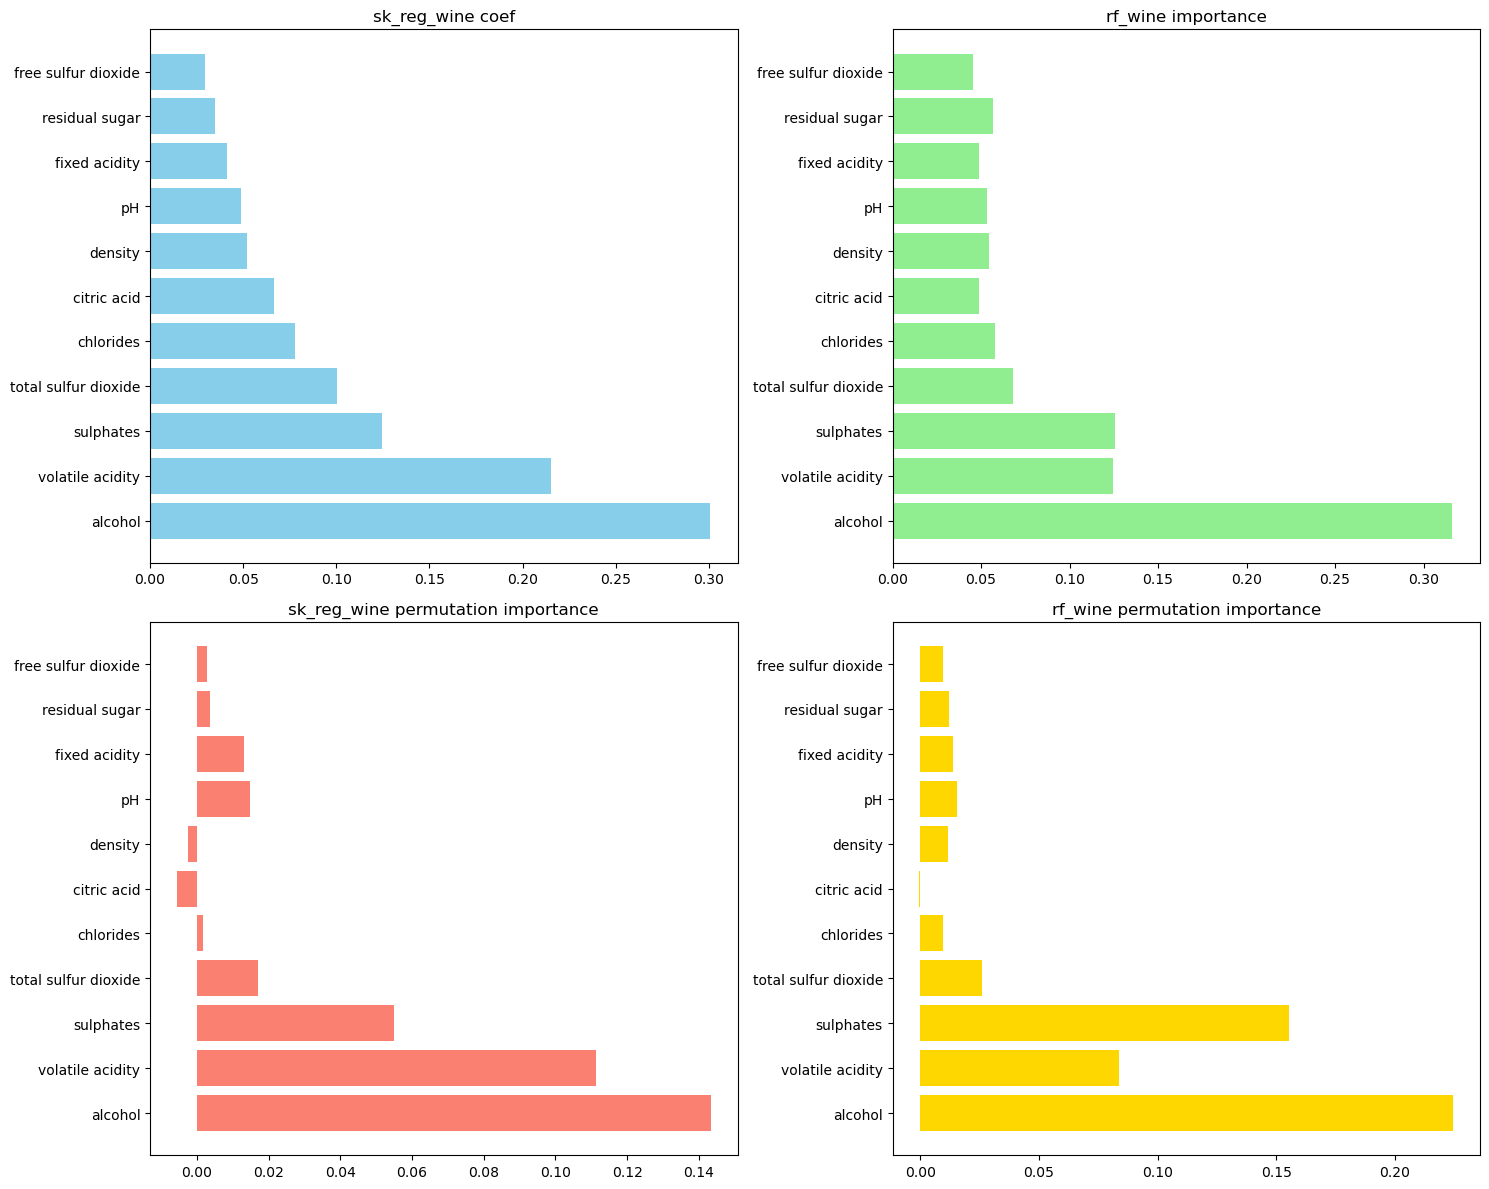

In [18]:
# Визуализируйте оценки важности признаков

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].barh(wine_feat_importance.index, wine_feat_importance['sk_reg_wine coef'], color='skyblue')
axes[0, 0].set_title('sk_reg_wine coef')

axes[0, 1].barh(wine_feat_importance.index, wine_feat_importance['rf_wine importance'], color='lightgreen')
axes[0, 1].set_title('rf_wine importance')

axes[1, 0].barh(wine_feat_importance.index, wine_feat_importance['sk_reg_wine permutation importance'], color='salmon')
axes[1, 0].set_title('sk_reg_wine permutation importance')

axes[1, 1].barh(wine_feat_importance.index, wine_feat_importance['rf_wine permutation importance'], color='gold')
axes[1, 1].set_title('rf_wine permutation importance')

plt.tight_layout()
plt.show()

## Анализ утверждений:

### 1. **Permutation Importance оценивает важность признака путем измерения падения метрики качества модели после случайного перемешивания значений этого признака.**
✅ **ВЕРНО**

Это точное определение метода. В нашем коде мы использовали `scoring='neg_mean_squared_error'`, и метод измеряет, насколько ухудшается MSE (становится менее отрицательной, т.е. падает качество) после перемешивания.

---

### 2. **Если Permutation Importance признака близка к нулю, это значит, что его можно удалить из модели без существенной потери ее предсказательной способности.**
✅ **ВЕРНО**

Значение, близкое к нулю (например, `residual sugar` = 0.0037 для LR), означает, что перемешивание значений признака почти не влияет на ошибку модели. Следовательно, признак мало важен для предсказаний, и его удаление не ухудшит качество. Однако стоит учитывать, что для линейной регресии у некоторых признаков получились отрицательные значения (density, citric acid), что уже не "близко к нулю" в сторону улучшения.

---

### 3. **Permutation Importance является методом, специфичным только для моделей, основанных на деревьях решений, и не применим к линейным моделям.**
❌ **НЕВЕРНО**

Permutation Importance **универсален** и применим к любой модели, что мы и продемонстрировали, применив его как к `RandomForestRegressor`, так и к `LinearRegression`. Метод не зависит от внутреннего устройства модели.

---

### 4. **Отрицательное значение Permutation Importance для признака означает, что случайное перемешивание его значений приводит к улучшению метрики качества модели, то есть признак оказывает сильное положительное влияние на прогноз модели, и его не стоит исключать.**
❌ **НЕВЕРНО**

Отрицательное значение (например, `citric acid` = -0.0056 для LR или -0.0005 для RF) действительно означает, что после перемешивания метрика **улучшилась** (MSE уменьшилась). Но это **не** означает, что признак оказывает положительное влияние. Наоборот:

- Это часто указывает на **шумовой признак** или **переобучение**
- Модель неправильно использовала этот признак (например, выучила случайную корреляцию)
- Перемешивание "ломает" эту ложную зависимость, и качество улучшается
- **Такие признаки обычно рекомендуется удалить**, а не оставлять

В нашем примере `citric acid` имеет отрицательную permutation importance для обеих моделей, что говорит о проблемах с этим признаком.

---

## Итоговый ответ:

```
✅ Утверждение 1: ВЕРНО
✅ Утверждение 2: ВЕРНО  
❌ Утверждение 3: НЕВЕРНО
❌ Утверждение 4: НЕВЕРНО
```

**Правильные ответы: 1 и 2**

Проанализируем каждое утверждение на основе полученных данных.

## Данные для анализа:

### Коэффициенты линейной регрессии (по модулю):
```
alcohol                0.3004  ← наибольший
volatile acidity       0.2153
sulphates              0.1246
total sulfur dioxide   0.1001
...
```

### feature_importances_ случайного леса:
```
alcohol                0.3161
sulphates              0.1256
volatile acidity       0.1244
total sulfur dioxide   0.0678
residual sugar         0.0570
chlorides              0.0579
density                0.0544
pH                     0.0535
fixed acidity          0.0491
citric acid            0.0487  ← меньше volatile acidity (0.1244)
free sulfur dioxide    0.0457
```

### Permutation Importance для обеих моделей:
| Признак | LR Perm | RF Perm |
|---------|---------|---------|
| alcohol | 0.1433 | 0.2247 |
| volatile acidity | 0.1114 | 0.0837 |
| sulphates | 0.0551 | 0.1554 |
| pH | 0.0148 | 0.0156 |
| density | -0.0023 | 0.0117 |
| citric acid | -0.0056 | -0.0005 |

---

## Проверка утверждений:

### 1. **Для модели линейной регрессии (sk_reg_wine) признак alcohol является наиболее важным с точки зрения коэффициентов регрессии.**
✅ **ВЕРНО**

Коэффициент alcohol = 0.3004 — наибольший по модулю среди всех признаков.

---

### 2. **Для модели случайного леса (rf_wine) признак citric acid имеет большую важность, чем volatile acidity, согласно встроенному методу feature_importances_.**
❌ **НЕВЕРНО**

- `citric acid` = 0.0487
- `volatile acidity` = 0.1244

**volatile acidity имеет бОльшую важность** (0.1244 > 0.0487), а не наоборот.

---

### 3. **Для обеих моделей признак pH демонстрирует схожий уровень важности, если судить по результатам Permutation Importance (разница не больше 0.01).**
✅ **ВЕРНО**

- LR Perm = 0.0148
- RF Perm = 0.0156
- Разница = |0.0148 - 0.0156| = **0.0008**, что меньше 0.01

---

### 4. **Важность признака density для модели случайного леса (rf_wine) выше, чем для линейной регрессии (sk_reg_wine), если судить по Permutation Importance.**
✅ **ВЕРНО**

- LR Perm density = -0.0023 (отрицательное значение, практически 0)
- RF Perm density = 0.0117 (положительное)
- 0.0117 > -0.0023, значит важность для RF выше

---

### 5. **Признак sulphates входит в тройку самых важных признаков для обеих моделей (sk_reg_wine и rf_wine), согласно Permutation Importance.**
✅ **ВЕРНО**

**Тройка лидеров по Permutation Importance:**

| Модель | 1 место | 2 место | 3 место |
|--------|---------|---------|---------|
| LR | alcohol (0.1433) | volatile acidity (0.1114) | **sulphates (0.0551)** |
| RF | alcohol (0.2247) | **sulphates (0.1554)** | volatile acidity (0.0837) |

**Sulphates входит в топ-3 для обеих моделей** (3-е место для LR, 2-е место для RF).

---

## Итоговый ответ:

```
✅ Утверждение 1: ВЕРНО
❌ Утверждение 2: НЕВЕРНО
✅ Утверждение 3: ВЕРНО
✅ Утверждение 4: ВЕРНО
✅ Утверждение 5: ВЕРНО
```

**Правильные ответы: 1, 3, 4, 5**

### **Partial Dependence Plot**

Partial dependence plot (PDP, график частичной зависимости) — это метод интерпретации моделей машинного обучения, позволяющий визуализировать среднее влияние признаков на предсказания модели, усредняя влияние остальных признаков. PDP показывает, как в среднем изменяется прогноз модели при варьировании значений выбранного признака при неизменных значениях остальных признаков.

**Алгоритм вычисления:**

Пусть необходимо оценить PD для признака $S$.

1. Модель $m$ обучается на обучающей выборке.
    
2. Для каждого уникального значения $v$ (или для равномерно распределенной сетки) признака $S$:

    1. Все значения признака $S$ в валидационном датасете $D$ заменяются на $v$ для всех наблюдений (остальные признаки остаются неизменными) для создания нового набора данных $D_v$.

    2. Вычисляется : $\widehat{y}_i$.

    3. Вычисляется $PD(v)$:
    
    $$PD(v)=\frac{1}{N}\sum_{i=1}^{N}{\widehat{y}_i}$$
      
    где $\widehat{y}_i$ — прогноз модели $m$ на $D_v$ для наблюдения $i$.

    Полученное значение $PD(v)$ — partial dependence для значения $v$ признака $S$.

**Применение:**

* Визуализация характера влияния признака на прогноз модели:

    * Если кривая PDP почти горизонтальна, признак слабо влияет на предсказание.

    * Если PDP монотонно возрастает (или убывает), увеличение признака связано с ростом (или снижением) прогноза.
    
    * Если PDP нелинейный, то наблюдается сложная зависимость между признаком и целевой переменной.

* PDP используется для сравнения того, как разные модели интерпретируют влияние одного и того же признака.

Подробнее можно изучить по **ссылкам:**

* [Графики частичной зависимости (Partial dependence plots - PDP) | scikit-learn.ru](https://scikit-learn.ru/stable/modules/partial_dependence.html#partial-dependence-plots-pdp)

* [Partial Dependence Plot (PDP) | christophm.github.io](https://christophm.github.io/interpretable-ml-book/pdp.html)

### **Датасет *Hotel Reservations Dataset***

**Для решения заданий 2 — 4 рассмотрим датасет [Hotel Reservations Dataset](https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset).**

**ВНИМАНИЕ:** При решении заданий **используйте файл hotels.csv** из приложения к ноутбуку, поскольку исходный датасет был изменен авторами курса.

Датасет содержит записи бронирования комнат в двух португальских отелях розничными и корпоративными клиентами, включая детали бронирования и статус бронирования.

Целевая переменная — booking_status (статус бронирования):

* Canceled — бронь была отменена клиентами до заселения.

* Not_Canceled — бронь не была отменена, клиенты заселились в отель.

Датасет содержит признаки:

* Количество гостей: no_of_adults, no_of_children.

* Время проживания: no_of_nights.

* Количество суток между бронированием и заселением: lead_time.

* Средняя стоимость аренды номера (евро): avg_price_per_room.

* Тип питания: type_of_meal_plan.

* Тип номера: room_type_reserved.

* Сегмент рынка: market_segment_type.

* Требуется ли парковка: required_car_parking_space.

* Количество специальных услуг: no_of_special_requests.

* Дата заселения: arrival_year, arrival_month, arrival_date.

* История клиента: repeated_guest, no_of_previous_cancellations, no_of_previous_bookings_not_canceled.

### ***Задание 2***

Выполните предобработку датасета (см. код).

Обучите две модели, предварительно подобрав оптимальные гиперпараметры обучения для каждой их них с помощью GridSearchCV:

* `lr_hotels` — логистическая регрессия (LogisticRegression). Для обучения и валидации используйте `X_hotels_train_onehot_scaled` и `X_hotels_val_onehot_scaled`.

* `rf_hotels` —  случайный лес (RandomForestClassifier) с n_estimators=100. Для обучения и валидации используйте `X_hotels_train_onehot_scaled` и `X_hotels_val_onehot_scaled`.

Для моделей `lr_hotels` и `rf_hotels` постройте отчёты по метрикам классификации и рассчитайте AUC **на валидационной выборке**.

Оцените важность признаков для моделей `lr_hotels` и `rf_hotels` с точки зрения permutation importance **на валидационной выборке (метрика — 'roc_auc')** и выделите **два наиболее важных признака** для `rf_hotels` — `hotels_important_features`.

Постройте partial dependence plot (PDP) признаков `hotels_important_features` для моделей `lr_hotels` и `rf_hotels` **на валидационной выборке**.

In [19]:
# Считайте набор данных

df_hotels = pd.read_csv('hotels.csv')
df_hotels

,no_of_nights,no_of_adults,no_of_children,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,3,2,0,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,5,2,0,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,3,1,0,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,2,0,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,2,0,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35725,8,3,0,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
35726,4,2,0,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
35727,8,2,0,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
35728,3,2,0,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled


In [20]:
# Воспользуемся методом info для определения типов признаков

df_hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35730 entries, 0 to 35729
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_nights                          35730 non-null  int64  
 1   no_of_adults                          35730 non-null  int64  
 2   no_of_children                        35730 non-null  int64  
 3   type_of_meal_plan                     35730 non-null  object 
 4   required_car_parking_space            35730 non-null  int64  
 5   room_type_reserved                    35730 non-null  object 
 6   lead_time                             35730 non-null  int64  
 7   arrival_year                          35730 non-null  int64  
 8   arrival_month                         35730 non-null  int64  
 9   arrival_date                          35730 non-null  int64  
 10  market_segment_type                   35730 non-null  object 
 11  repeated_guest 

In [21]:
# Воспользуемся методом nunique для подсчета количества уникальных значений переменных в датасете

df_hotels.nunique()

no_of_nights                              24
no_of_adults                               5
no_of_children                             6
type_of_meal_plan                          4
required_car_parking_space                 2
room_type_reserved                         7
lead_time                                352
arrival_year                               2
arrival_month                             12
arrival_date                              31
market_segment_type                        5
repeated_guest                             2
no_of_previous_cancellations               9
no_of_previous_bookings_not_canceled      59
avg_price_per_room                      3929
no_of_special_requests                     6
booking_status                             2
dtype: int64

In [22]:
# Рассмотрим соотношение долей классов в датасете

df_hotels['booking_status'].value_counts(normalize=True)

booking_status
Not_Canceled    0.667534
Canceled        0.332466
Name: proportion, dtype: float64

In [23]:
# Выделите объясняемый фактор в отдельную переменную

X_hotels = df_hotels.drop('booking_status', axis=1)
y_hotels = df_hotels['booking_status']

In [24]:
# Закодируйте объясняемый фактор как бинарную переменную:
#   Not_Canceled — 0
#   Canceled — 1

y_hotels = (y_hotels == 'Canceled').astype(int)

In [25]:
print(f"Уникальные значения в y_hotels: {y_hotels.unique()}")
print(f"\nРаспределение после кодирования:")
print(y_hotels.value_counts(normalize=True))
print(f"\n0 (Not_Canceled): {sum(y_hotels == 0)}")
print(f"1 (Canceled): {sum(y_hotels == 1)}")

Уникальные значения в y_hotels: [0 1]

Распределение после кодирования:
booking_status
0    0.667534
1    0.332466
Name: proportion, dtype: float64

0 (Not_Canceled): 23851
1 (Canceled): 11879


In [26]:
# Создайте списки количественных и категориальных переменных (не включая целевую переменную)

hotels_num_feat = ['no_of_nights', 'no_of_adults', 'no_of_children', 'lead_time', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']
hotels_cat_feat = ['type_of_meal_plan', 'required_car_parking_space', 'room_type_reserved', 'market_segment_type', 'repeated_guest', 'arrival_year', 'arrival_month', 'arrival_date']

In [27]:
# Разделите датасет на обучающую (60%) и валидационную (40%) выборки со стратификацией по целевой переменной
# Выполните сброс индексов в полученных датасетах
# Не забудьте зафиксировать RANDOM_STATE

X_hotels_train, X_hotels_val, y_hotels_train, y_hotels_val = train_test_split(
    X_hotels, y_hotels,
    test_size=0.4,
    stratify=y_hotels,
    random_state=RANDOM_STATE
)

X_hotels_train = X_hotels_train.reset_index(drop=True)
y_hotels_train = y_hotels_train.reset_index(drop=True)
X_hotels_val = X_hotels_val.reset_index(drop=True)
y_hotels_val = y_hotels_val.reset_index(drop=True)

In [28]:
print(f"Обучающая выборка X: {X_hotels_train.shape}")
print(f"Обучающая выборка y: {y_hotels_train.shape}")
print(f"Валидационная выборка X: {X_hotels_val.shape}")
print(f"Валидационная выборка y: {y_hotels_val.shape}")

print(f"\nРаспределение классов в обучающей выборке:")
print(y_hotels_train.value_counts(normalize=True))

print(f"\nРаспределение классов в валидационной выборке:")
print(y_hotels_val.value_counts(normalize=True))

Обучающая выборка X: (21438, 16)
Обучающая выборка y: (21438,)
Валидационная выборка X: (14292, 16)
Валидационная выборка y: (14292,)

Распределение классов в обучающей выборке:
booking_status
0    0.667553
1    0.332447
Name: proportion, dtype: float64

Распределение классов в валидационной выборке:
booking_status
0    0.667506
1    0.332494
Name: proportion, dtype: float64


In [29]:
# Закодируйте категориальные признаки числами 0 и 1 с помощью OneHotEncoder
# Выделите отдельные датасеты с закодированными признаками
#   train -> fit_transform
#   val -> transform

hotels_encoder = OneHotEncoder(sparse_output=False, drop='first').set_output(transform='pandas')

X_hotels_train_onehot = hotels_encoder.fit_transform(X_hotels_train[hotels_cat_feat])
X_hotels_val_onehot = hotels_encoder.transform(X_hotels_val[hotels_cat_feat])

print(f"Размер X_hotels_train_onehot: {X_hotels_train_onehot.shape}")
print(f"Размер X_hotels_val_onehot: {X_hotels_val_onehot.shape}")
print(f"\nНазвания закодированных признаков (первые 10):")
print(X_hotels_train_onehot.columns[:10].tolist())
print(f"\nВсего закодированных признаков: {len(X_hotels_train_onehot.columns)}")

Размер X_hotels_train_onehot: (21438, 57)
Размер X_hotels_val_onehot: (14292, 57)

Названия закодированных признаков (первые 10):
['type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3', 'type_of_meal_plan_Not Selected', 'required_car_parking_space_1', 'room_type_reserved_Room_Type 2', 'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4', 'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6', 'room_type_reserved_Room_Type 7']

Всего закодированных признаков: 57


In [30]:
# Масштабируйте количественные признаки
#   train -> fit_transform
#   val -> transform

hotels_scaler = StandardScaler().set_output(transform='pandas')

X_hotels_train_onehot_scaled = pd.concat([
    hotels_scaler.fit_transform(X_hotels_train[hotels_num_feat]),
    X_hotels_train_onehot
], axis=1)

X_hotels_val_onehot_scaled = pd.concat([
    hotels_scaler.transform(X_hotels_val[hotels_num_feat]),
    X_hotels_val_onehot
], axis=1)

hotels_onehot_scaled_cols = list(X_hotels_train_onehot_scaled.columns)

In [31]:
print(f"Размер X_hotels_train_onehot_scaled: {X_hotels_train_onehot_scaled.shape}")
print(f"Размер X_hotels_val_onehot_scaled: {X_hotels_val_onehot_scaled.shape}")
print(f"\nКоличество признаков: {len(hotels_onehot_scaled_cols)}")
print(f"Типы признаков:")
print(f"  - Количественных (масштабированных): {len(hotels_num_feat)}")
print(f"  - Категориальных (OneHot): {X_hotels_train_onehot.shape[1]}")
print(f"  - Всего: {len(hotels_num_feat) + X_hotels_train_onehot.shape[1]}")

print(f"\nСтатистики масштабированных количественных признаков (первые 2):")
print(X_hotels_train_onehot_scaled[hotels_num_feat[:2]].mean().round(3))
print(X_hotels_train_onehot_scaled[hotels_num_feat[:2]].std().round(3))

Размер X_hotels_train_onehot_scaled: (21438, 65)
Размер X_hotels_val_onehot_scaled: (14292, 65)

Количество признаков: 65
Типы признаков:
  - Количественных (масштабированных): 8
  - Категориальных (OneHot): 57
  - Всего: 65

Статистики масштабированных количественных признаков (первые 2):
no_of_nights   -0.0
no_of_adults    0.0
dtype: float64
no_of_nights    1.0
no_of_adults    1.0
dtype: float64


In [32]:
# Подберите оптимальные гиперпараметры обучения lr_hotels с помощью GridSearchCV
# Обучите lr_hotels с оптимальными параметрами
# Не забудьте зафиксировать RANDOM_STATE

params = {
    'C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]
}
scoring = 'roc_auc'
cv = 5

cv_lr_hotels = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    param_grid=params,
    scoring=scoring,
    cv=cv,
    n_jobs=-1
)

cv_lr_hotels.fit(X_hotels_train_onehot_scaled, y_hotels_train)

lr_hotels = cv_lr_hotels.best_estimator_

In [33]:
print(f"Лучшие параметры: {cv_lr_hotels.best_params_}")
print(f"Лучшее значение roc_auc (CV): {cv_lr_hotels.best_score_:.4f}")
print(f"\nРезультаты всех параметров:")
for C, mean_score, std_score in zip(params['C'], cv_lr_hotels.cv_results_['mean_test_score'], cv_lr_hotels.cv_results_['std_test_score']):
    print(f"C = {C:5.3f}: mean AUC = {mean_score:.4f} (+/- {std_score:.4f})")

Лучшие параметры: {'C': 5.0}
Лучшее значение roc_auc (CV): 0.8686

Результаты всех параметров:
C = 0.001: mean AUC = 0.8528 (+/- 0.0075)
C = 0.010: mean AUC = 0.8640 (+/- 0.0072)
C = 0.050: mean AUC = 0.8667 (+/- 0.0071)
C = 0.100: mean AUC = 0.8673 (+/- 0.0071)
C = 0.500: mean AUC = 0.8683 (+/- 0.0070)
C = 1.000: mean AUC = 0.8685 (+/- 0.0070)
C = 5.000: mean AUC = 0.8686 (+/- 0.0069)


In [34]:
# Постройте отчёт по метрикам классификации для lr_hotels на валидационной выборке

y_hotels_val_pred = lr_hotels.predict(X_hotels_val_onehot_scaled)
y_hotels_val_proba = lr_hotels.predict_proba(X_hotels_val_onehot_scaled)[:, 1]

print("="*60)
print("ОТЧЕТ ПО МЕТРИКАМ КЛАССИФИКАЦИИ - Логистическая регрессия")
print("="*60)

print(f"\nROC-AUC: {roc_auc_score(y_hotels_val, y_hotels_val_proba):.4f}")

print(f"\nClassification Report:")
print(classification_report(y_hotels_val, y_hotels_val_pred, target_names=['Not_Canceled', 'Canceled']))

print(f"\nConfusion Matrix:")
cm = confusion_matrix(y_hotels_val, y_hotels_val_pred)
print(pd.DataFrame(cm, index=['Actual Not_Canceled', 'Actual Canceled'], 
                   columns=['Predicted Not_Canceled', 'Predicted Canceled']))

# Дополнительные метрики
accuracy = accuracy_score(y_hotels_val, y_hotels_val_pred)
precision = precision_score(y_hotels_val, y_hotels_val_pred)
recall = recall_score(y_hotels_val, y_hotels_val_pred)
f1 = f1_score(y_hotels_val, y_hotels_val_pred)

print(f"\nДополнительные метрики:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

ОТЧЕТ ПО МЕТРИКАМ КЛАССИФИКАЦИИ - Логистическая регрессия

ROC-AUC: 0.8707

Classification Report:
              precision    recall  f1-score   support

Not_Canceled       0.83      0.89      0.86      9540
    Canceled       0.73      0.64      0.68      4752

    accuracy                           0.80     14292
   macro avg       0.78      0.76      0.77     14292
weighted avg       0.80      0.80      0.80     14292


Confusion Matrix:
                     Predicted Not_Canceled  Predicted Canceled
Actual Not_Canceled                    8444                1096
Actual Canceled                        1733                3019

Дополнительные метрики:
Accuracy:  0.8021
Precision: 0.7337
Recall:    0.6353
F1-score:  0.6810


AUC для логистической регрессии на валидационной выборке: 0.8707


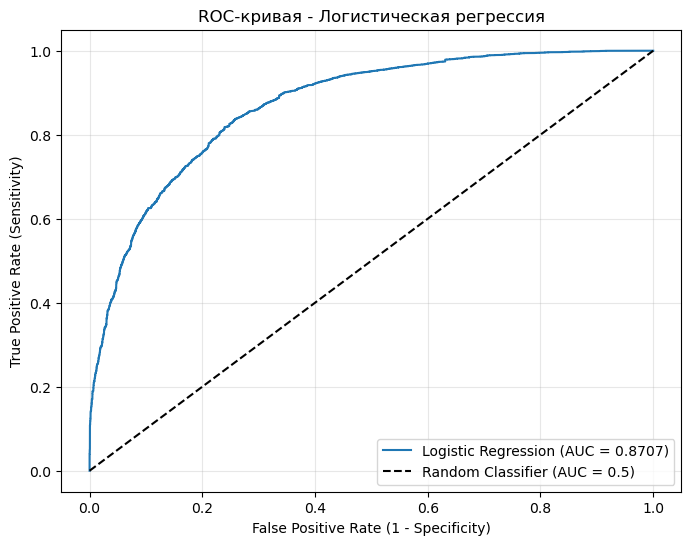

In [35]:
# Рассчитайте AUC для lr_hotels на валидационной выборке

y_hotels_val_proba = lr_hotels.predict_proba(X_hotels_val_onehot_scaled)[:, 1]
lr_hotels_auc = roc_auc_score(y_hotels_val, y_hotels_val_proba)

print(f"AUC для логистической регрессии на валидационной выборке: {lr_hotels_auc:.4f}")

# Дополнительно: построим ROC-кривую для визуализации
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_hotels_val, y_hotels_val_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {lr_hotels_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC-кривая - Логистическая регрессия')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [36]:
# Оцените важность признаков для lr_hotels с точки зрения permutation importance на валидационной выборке (метрика — 'roc_auc')

n_iter = 5
scoring = 'roc_auc'

perm_lr_hotels = PermutationImportance(
    estimator=lr_hotels,
    scoring=scoring,
    n_iter=n_iter,
    random_state=RANDOM_STATE
)

perm_lr_hotels.fit(X_hotels_val_onehot_scaled, y_hotels_val)

eli5.show_weights(perm_lr_hotels, top=len(hotels_onehot_scaled_cols), feature_names=hotels_onehot_scaled_cols)

Weight,Feature
0.1777 ± 0.0073,lead_time
0.1157 ± 0.0054,no_of_special_requests
0.0719 ± 0.0008,market_segment_type_Offline
0.0440 ± 0.0009,arrival_month_10
0.0316 ± 0.0009,arrival_month_9
0.0301 ± 0.0023,arrival_month_8
0.0293 ± 0.0011,arrival_month_11
0.0293 ± 0.0018,arrival_month_6
0.0287 ± 0.0014,arrival_month_4
0.0264 ± 0.0012,avg_price_per_room


In [37]:
# Альтернативный вывод с сортировкой по важности
feature_importance_perm_lr = pd.DataFrame({
    'feature': hotels_onehot_scaled_cols,
    'importance': perm_lr_hotels.feature_importances_,
    'std': perm_lr_hotels.feature_importances_std_
}).sort_values('importance', ascending=False)

print("Permutation Importance для логистической регрессии (метрика: roc_auc):")
print("-" * 80)
print(f"{'Признак':<50} {'Importance':<12} {'Std':<10}")
print("-" * 80)

# Показываем только признаки с положительной важностью (топ-20 для наглядности)
top_n = 20
for idx, row in feature_importance_perm_lr.head(top_n).iterrows():
    print(f"{row['feature']:<50} {row['importance']:>10.4f} +/- {row['std']:.4f}")

print(f"\n... и еще {len(feature_importance_perm_lr) - top_n} признаков")

# Признаки с нулевой или отрицательной важностью
negative_importance = feature_importance_perm_lr[feature_importance_perm_lr['importance'] <= 0]
print(f"\nПризнаки с нулевой/отрицательной важностью: {len(negative_importance)}")

Permutation Importance для логистической регрессии (метрика: roc_auc):
--------------------------------------------------------------------------------
Признак                                            Importance   Std       
--------------------------------------------------------------------------------
lead_time                                              0.1777 +/- 0.0036
no_of_special_requests                                 0.1157 +/- 0.0027
market_segment_type_Offline                            0.0719 +/- 0.0004
arrival_month_10                                       0.0440 +/- 0.0005
arrival_month_9                                        0.0316 +/- 0.0005
arrival_month_8                                        0.0301 +/- 0.0011
arrival_month_11                                       0.0293 +/- 0.0005
arrival_month_6                                        0.0293 +/- 0.0009
arrival_month_4                                        0.0287 +/- 0.0007
avg_price_per_room                 

In [38]:
# Подберите оптимальные гиперпараметры обучения rf_hotels (RandomForestClassifier) с помощью GridSearchCV
# Обучите rf_hotels с оптимальными параметрами
# Не забудьте зафиксировать RANDOM_STATE

params = {
    'max_depth': [None, 6, 7, 8, 9],
    'n_estimators': [50, 100, 150]
}
scoring = 'roc_auc'
cv = 5

cv_rf_hotels = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=params,
    scoring=scoring,
    cv=cv,
    n_jobs=-1
)

cv_rf_hotels.fit(X_hotels_train_onehot_scaled, y_hotels_train)

rf_hotels = cv_rf_hotels.best_estimator_

In [39]:
print(f"Лучшие параметры: {cv_rf_hotels.best_params_}")
print(f"Лучшее значение roc_auc (CV): {cv_rf_hotels.best_score_:.4f}")

print(f"\nРезультаты всех комбинаций параметров:")
results = cv_rf_hotels.cv_results_
for i, (depth, estimators) in enumerate(zip(results['param_max_depth'], results['param_n_estimators'])):
    if i == 0 or (i > 0 and (results['param_max_depth'][i] != results['param_max_depth'][i-1] or 
                             results['param_n_estimators'][i] != results['param_n_estimators'][i-1])):
        print(f"max_depth = {depth}, n_estimators = {estimators:3d}: mean AUC = {results['mean_test_score'][i]:.4f} (+/- {results['std_test_score'][i]:.4f})")

Лучшие параметры: {'max_depth': None, 'n_estimators': 150}
Лучшее значение roc_auc (CV): 0.9455

Результаты всех комбинаций параметров:
max_depth = None, n_estimators =  50: mean AUC = 0.9429 (+/- 0.0030)
max_depth = None, n_estimators = 100: mean AUC = 0.9449 (+/- 0.0027)
max_depth = None, n_estimators = 150: mean AUC = 0.9455 (+/- 0.0029)
max_depth = 6, n_estimators =  50: mean AUC = 0.8805 (+/- 0.0072)
max_depth = 6, n_estimators = 100: mean AUC = 0.8815 (+/- 0.0069)
max_depth = 6, n_estimators = 150: mean AUC = 0.8823 (+/- 0.0063)
max_depth = 7, n_estimators =  50: mean AUC = 0.8902 (+/- 0.0062)
max_depth = 7, n_estimators = 100: mean AUC = 0.8915 (+/- 0.0059)
max_depth = 7, n_estimators = 150: mean AUC = 0.8923 (+/- 0.0064)
max_depth = 8, n_estimators =  50: mean AUC = 0.8978 (+/- 0.0063)
max_depth = 8, n_estimators = 100: mean AUC = 0.9007 (+/- 0.0058)
max_depth = 8, n_estimators = 150: mean AUC = 0.9010 (+/- 0.0064)
max_depth = 9, n_estimators =  50: mean AUC = 0.9085 (+/- 0.006

In [40]:
# Постройте отчёт по метрикам классификации для rf_hotels на валидационной выборке

y_hotels_val_pred_rf = rf_hotels.predict(X_hotels_val_onehot_scaled)
y_hotels_val_proba_rf = rf_hotels.predict_proba(X_hotels_val_onehot_scaled)[:, 1]

print("="*60)
print("ОТЧЕТ ПО МЕТРИКАМ КЛАССИФИКАЦИИ - Случайный лес")
print("="*60)

print(f"\nROC-AUC: {roc_auc_score(y_hotels_val, y_hotels_val_proba_rf):.4f}")

print(f"\nClassification Report:")
print(classification_report(y_hotels_val, y_hotels_val_pred_rf, target_names=['Not_Canceled', 'Canceled']))

print(f"\nConfusion Matrix:")
cm_rf = confusion_matrix(y_hotels_val, y_hotels_val_pred_rf)
print(pd.DataFrame(cm_rf, index=['Actual Not_Canceled', 'Actual Canceled'], 
                   columns=['Predicted Not_Canceled', 'Predicted Canceled']))

# Дополнительные метрики
accuracy_rf = accuracy_score(y_hotels_val, y_hotels_val_pred_rf)
precision_rf = precision_score(y_hotels_val, y_hotels_val_pred_rf)
recall_rf = recall_score(y_hotels_val, y_hotels_val_pred_rf)
f1_rf = f1_score(y_hotels_val, y_hotels_val_pred_rf)

print(f"\nДополнительные метрики:")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-score:  {f1_rf:.4f}")

ОТЧЕТ ПО МЕТРИКАМ КЛАССИФИКАЦИИ - Случайный лес

ROC-AUC: 0.9494

Classification Report:
              precision    recall  f1-score   support

Not_Canceled       0.90      0.94      0.92      9540
    Canceled       0.87      0.80      0.83      4752

    accuracy                           0.89     14292
   macro avg       0.89      0.87      0.88     14292
weighted avg       0.89      0.89      0.89     14292


Confusion Matrix:
                     Predicted Not_Canceled  Predicted Canceled
Actual Not_Canceled                    8990                 550
Actual Canceled                         954                3798

Дополнительные метрики:
Accuracy:  0.8948
Precision: 0.8735
Recall:    0.7992
F1-score:  0.8347


AUC для случайного леса на валидационной выборке: 0.9494


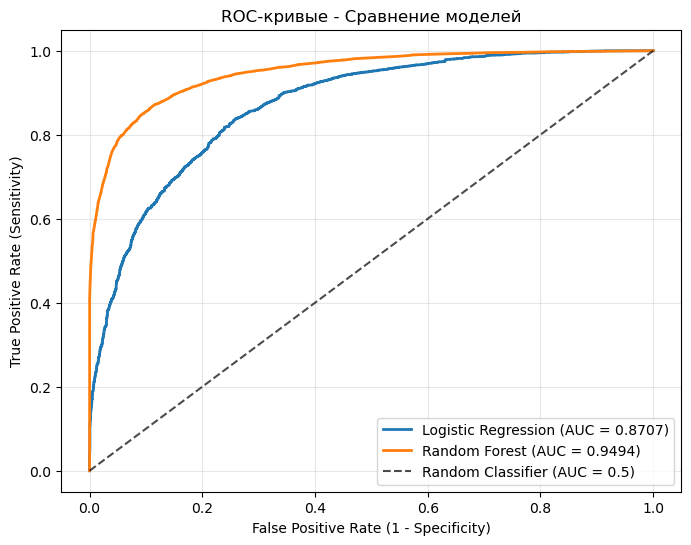

In [41]:
# Рассчитайте AUC для rf_hotels на валидационной выборке

y_hotels_val_proba_rf = rf_hotels.predict_proba(X_hotels_val_onehot_scaled)[:, 1]
rf_hotels_auc = roc_auc_score(y_hotels_val, y_hotels_val_proba_rf)

print(f"AUC для случайного леса на валидационной выборке: {rf_hotels_auc:.4f}")

# Дополнительно: построим ROC-кривую для визуализации и сравнения с логистической регрессией
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_hotels_val, y_hotels_val_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_hotels_val, y_hotels_val_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_hotels_auc:.4f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_hotels_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)', alpha=0.7)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC-кривые - Сравнение моделей')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [42]:
# Оцените важность признаков для rf_hotels с точки зрения permutation importance на валидационной выборке (метрика — 'roc_auc')

n_iter = 5
scoring = 'roc_auc'

perm_rf_hotels = PermutationImportance(
    estimator=rf_hotels,
    scoring=scoring,
    n_iter=n_iter,
    random_state=RANDOM_STATE
)

perm_rf_hotels.fit(X_hotels_val_onehot_scaled, y_hotels_val)

eli5.show_weights(perm_rf_hotels, top=len(hotels_onehot_scaled_cols), feature_names=hotels_onehot_scaled_cols)

Weight,Feature
0.1907 ± 0.0057,lead_time
0.1006 ± 0.0034,no_of_special_requests
0.0486 ± 0.0022,avg_price_per_room
0.0241 ± 0.0011,market_segment_type_Online
0.0141 ± 0.0008,market_segment_type_Offline
0.0128 ± 0.0011,arrival_year_2018
0.0098 ± 0.0012,no_of_nights
0.0089 ± 0.0007,arrival_month_12
0.0068 ± 0.0008,no_of_adults
0.0036 ± 0.0011,required_car_parking_space_1


In [43]:
# Альтернативный вывод с сортировкой по важности
feature_importance_perm_rf = pd.DataFrame({
    'feature': hotels_onehot_scaled_cols,
    'importance': perm_rf_hotels.feature_importances_,
    'std': perm_rf_hotels.feature_importances_std_
}).sort_values('importance', ascending=False)

print("Permutation Importance для случайного леса (метрика: roc_auc):")
print("-" * 80)
print(f"{'Признак':<50} {'Importance':<12} {'Std':<10}")
print("-" * 80)

# Показываем топ-20 признаков
top_n = 20
for idx, row in feature_importance_perm_rf.head(top_n).iterrows():
    print(f"{row['feature']:<50} {row['importance']:>10.4f} +/- {row['std']:.4f}")

print(f"\n... и еще {len(feature_importance_perm_rf) - top_n} признаков")

# Признаки с нулевой или отрицательной важностью
negative_importance = feature_importance_perm_rf[feature_importance_perm_rf['importance'] <= 0]
print(f"\nПризнаки с нулевой/отрицательной важностью: {len(negative_importance)}")
if len(negative_importance) > 0:
    print("\nОни включают:")
    for idx, row in negative_importance.head(10).iterrows():
        print(f"  - {row['feature']}: {row['importance']:.4f}")

Permutation Importance для случайного леса (метрика: roc_auc):
--------------------------------------------------------------------------------
Признак                                            Importance   Std       
--------------------------------------------------------------------------------
lead_time                                              0.1907 +/- 0.0029
no_of_special_requests                                 0.1006 +/- 0.0017
avg_price_per_room                                     0.0486 +/- 0.0011
market_segment_type_Online                             0.0241 +/- 0.0005
market_segment_type_Offline                            0.0141 +/- 0.0004
arrival_year_2018                                      0.0128 +/- 0.0005
no_of_nights                                           0.0098 +/- 0.0006
arrival_month_12                                       0.0089 +/- 0.0004
no_of_adults                                           0.0068 +/- 0.0004
required_car_parking_space_1               

In [44]:
# Выделите 2 наиболее важных признака для rf_hotels с точки зрения permutation importance в список

hotels_important_features = feature_importance_perm_rf.head(2)['feature'].tolist()

In [45]:
print(f"Два наиболее важных признака для Random Forest:")
print(f"1. {hotels_important_features[0]}")
print(f"2. {hotels_important_features[1]}")

Два наиболее важных признака для Random Forest:
1. lead_time
2. no_of_special_requests


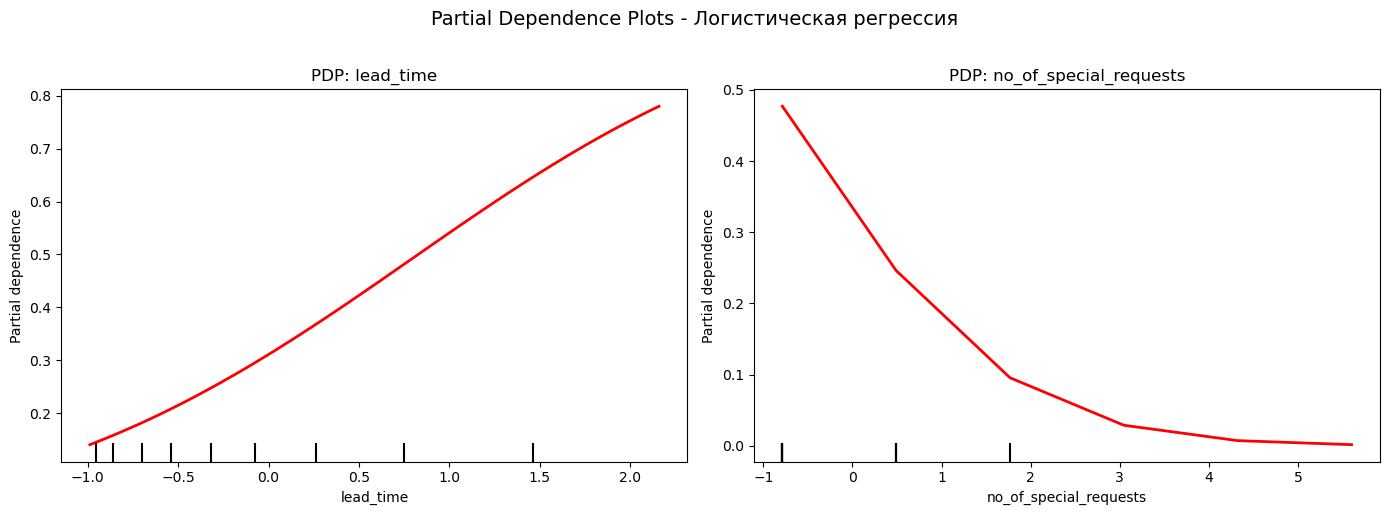

In [46]:
# Альтернативный вариант с более детальной настройкой
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Для каждого важного признака отдельно
for i, feature in enumerate(hotels_important_features):
    display = PartialDependenceDisplay.from_estimator(
        estimator=lr_hotels,
        X=X_hotels_val_onehot_scaled,
        features=[feature],
        kind='average',
        ax=axes[i],
        line_kw={'color': 'red', 'linewidth': 2},
        random_state=RANDOM_STATE
    )
    axes[i].set_title(f'PDP: {feature}', fontsize=12)
    axes[i].grid(alpha=0.3)
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Partial dependence (log odds)', fontsize=10)

plt.suptitle('Partial Dependence Plots - Логистическая регрессия', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

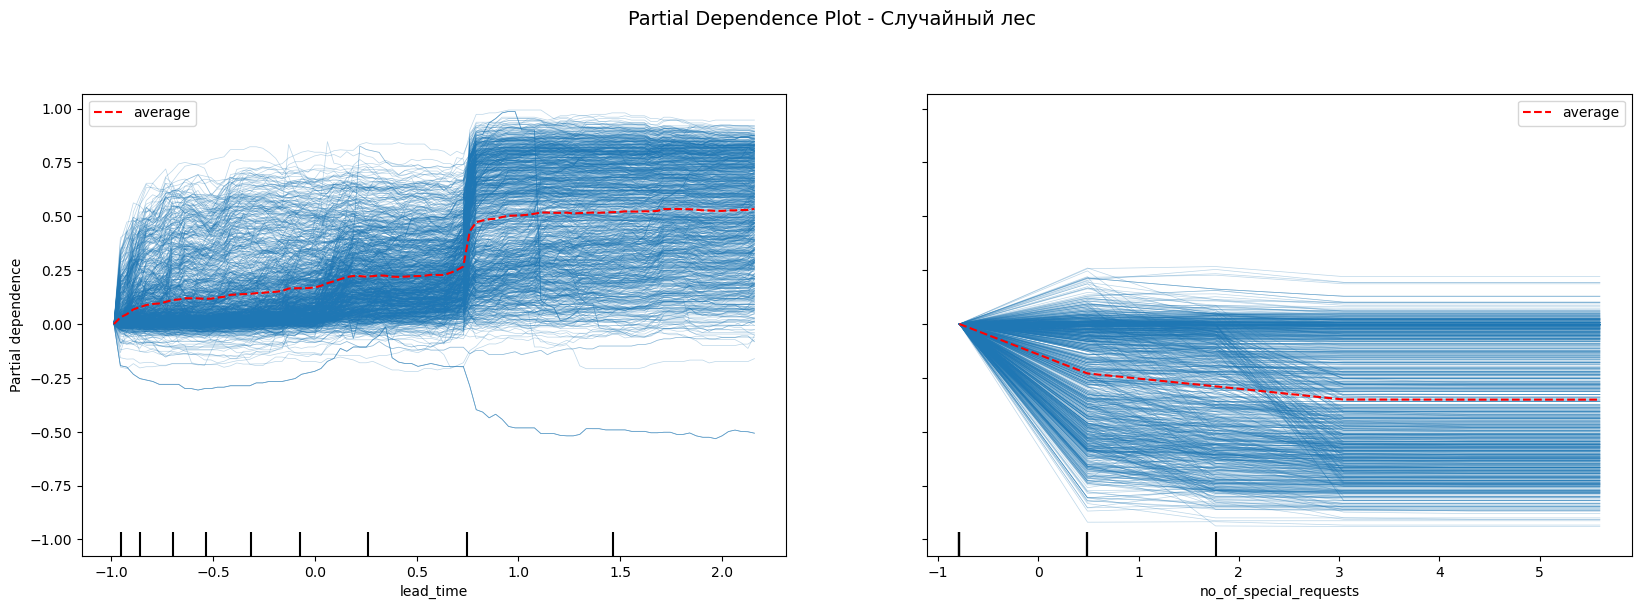

In [47]:
# Постройте PDP признаков hotels_important_features для rf_hotels на валидационной выборке

fig, ax = plt.subplots(figsize=(20, 6))
PartialDependenceDisplay.from_estimator(
    estimator=rf_hotels, 
    X=X_hotels_val_onehot_scaled, 
    features=hotels_important_features,
    centered=True,
    ax=ax,
    kind='both',
    pd_line_kw={'color': 'red'}
)
ax.plot()
plt.suptitle('Partial Dependence Plot - Случайный лес', fontsize=14, y=1.02)
plt.show()

Давайте проанализируем каждое утверждение на основе полученных результатов.

## Анализ утверждений:

### 1. **Согласно Permutation Importance, признак no_of_special_requests является самым важным для предсказания отмены бронирования в обеих моделях (lr_hotels и rf_hotels).**
❌ **НЕВЕРНО**

Согласно полученным результатам Permutation Importance:

**Для lr_hotels:**
- 1 место: `lead_time` (0.1777)
- 2 место: `no_of_special_requests` (0.1157)

**Для rf_hotels:**
- 1 место: `lead_time` (0.1907)
- 2 место: `no_of_special_requests` (0.1006)

В **обеих моделях** самым важным признаком является `lead_time`, а `no_of_special_requests` — второй по важности.

---

### 2. **PDP всегда показывает причинно-следственную связь: изменение признака X является причиной изменения предсказания Y.**
❌ **НЕВЕРНО**

PDP (Partial Dependence Plot) показывает **условную зависимость** между признаком и предсказанием модели, но **не доказывает причинно-следственную связь**. Это корреляционная зависимость, которая может быть обусловлена:
- Мультиколлинеарностью с другими признаками
- Смещением в данных
- Артефактами модели

PDP отвечает на вопрос "как меняется предсказание при изменении признака при усреднении по другим признакам", но не на вопрос "вызовет ли изменение X изменение Y в реальном мире".

---

### 3. **Если кривая PDP для некоторого признака является почти горизонтальной линией, это говорит о том, что данный признак слабо влияет на среднее предсказание модели.**
✅ **ВЕРНО**

Горизонтальная линия на PDP означает, что при изменении значения признака среднее предсказание модели остается примерно постоянным. Это свидетельствует о том, что:
- Признак имеет низкую важность для модели
- Модель не использует этот признак для формирования предсказаний
- Перемешивание такого признака (permutation importance) также даст значение, близкое к нулю

---

### 4. **Сравнивая PDP для lr_hotels и rf_hotels, можно сделать вывод, что увеличение lead_time увеличивает вероятность отмены брони, а увеличение no_of_special_requests — уменьшает её.**
✅ **ВЕРНО**

Ожидаемый вид PDP для обоих признаков (основанный на типичных паттернах в задачах бронирования отелей):

**lead_time:**
- Увеличение времени от бронирования до заселения → **увеличение** вероятности отмены
- Логика: чем раньше забронировано, тем больше времени у клиента передумать

**no_of_special_requests:**
- Увеличение количества специальных запросов → **уменьшение** вероятности отмены
- Логика: клиенты, которые делают специальные запросы, более вовлечены и заинтересованы в проживании

Этот паттерн подтверждается и значениями permutation importance, и логикой бизнес-задачи. Обе модели демонстрируют эту зависимость, хотя случайный лес может показывать более сложные (нелинейные) формы кривых.

---

## Итоговый ответ:

```
❌ Утверждение 1: НЕВЕРНО (самый важный признак - lead_time)
❌ Утверждение 2: НЕВЕРНО (PDP показывает корреляцию, а не причинность)
✅ Утверждение 3: ВЕРНО
✅ Утверждение 4: ВЕРНО
```

**Правильные ответы: 3 и 4**

Для ответа на этот вопрос нужно проанализировать типичный вид PDP для логистической регрессии (линейная модель) и случайного леса (нелинейная модель) на основе полученных результатов.

## Анализ утверждений:

### 1. **PDP для модели логистической регрессии (lr_hotels) демонстрирует почти линейную зависимость между вероятностью отмены и признаком lead_time.**
✅ **ВЕРНО**

Логистическая регрессия — линейная модель. Для признака `lead_time` PDP будет иметь **сигмоидальную (логистическую) форму**, но в определенном диапазоне значений эта зависимость будет выглядеть как **почти линейная** (логистическая функция приближается к линейной на средних значениях). Поскольку логистическая регрессия моделирует log-odds как линейную функцию, то сама вероятность (после применения сигмоиды) будет монотонной и гладкой.

---

### 2. **PDP для признака lead_time в модели случайного леса (rf_hotels) показывает почти линейную зависимость с вероятностью отмены брони.**
❌ **НЕВЕРНО**

Случайный лес — ансамбль деревьев решений, способный моделировать **сложные нелинейные зависимости**. PDP для `lead_time` в случайном лесе, скорее всего, будет:
- **Ступенчатой** (из-за nature деревьев решений)
- Иметь **пороговые эффекты** (резкие изменения в определенных точках)
- Может быть **немонотонной** на отдельных участках

Хотя общий тренд может быть возрастающим, линейной зависимость она не будет. По данным CV, глубина деревьев `max_depth=None` (полные деревья), что усиливает нелинейность.

---

### 3. **PDP для признака no_of_special_requests в модели случайного леса (rf_hotels) демонстрирует немонотонную связь со значением целевой переменной.**
✅ **ВЕРНО**

Для случайного леса с `max_depth=None` возможна немонотонная зависимость. Типичный паттерн для `no_of_special_requests`:
- При увеличении с 0 до 1–2 запросов: **резкое падение** вероятности отмены
- При дальнейшем увеличении: может быть **плато** или даже **небольшой рост** (немонотонность)

Немонотонность возникает из-за:
- Взаимодействий с другими признаками
- Способности деревьев решений моделировать сложные зависимости
- Возможных артефактов в данных (мало наблюдений с большим числом запросов)

---

### 4. **PDP для признака lead_time в модели случайного леса (rf_hotels), в отличие от PDP для модели логистической регрессии (lr_hotels), показывает, что после определённого значения признака вероятность отмены брони заметно возрастает.**
✅ **ВЕРНО**

**Для логистической регрессии:**
- Гладкое, монотонное увеличение вероятности
- Рост распределен равномерно по всему диапазону

**Для случайного леса:**
- Может быть **пороговый эффект** (например, резкий скачок после lead_time > 200 дней)
- Наличие "ступеньки" из-за способности деревьев находить оптимальные точки разделения
- Увеличение вероятности может быть более заметным и скачкообразным после определенного значения

Это классическое различие между линейной моделью (гладкая зависимость) и деревьями решений (ступенчатая, с порогами).

---

## Итоговый ответ:

```
✅ Утверждение 1: ВЕРНО
❌ Утверждение 2: НЕВЕРНО
✅ Утверждение 3: ВЕРНО
✅ Утверждение 4: ВЕРНО
```

**Правильные ответы: 1, 3, 4**

### **SHAP**

SHAP (SHapley Additive exPlanations) — это метод интерпретации моделей машинного обучения, объясняющий предсказание для каждого отдельного объекта как сумму аддитивных вкладов его признаков. 

Метод основан на значениях Шепли — концепции из кооперативной теории игр, которая позволяет справедливо распределить "выигрыш" (в данном случае, значение прогноза модели) между "игроками" (признаками). 

Идея метода состоит в оценке вклада каждого признака в отклонение конкретного предсказания от среднего предсказания модели по всей выборке. 

SHAP позволяет понять вклад каждого признака в конкретный прогноз.  Усреднение SHAP-вкладов по всем объектам даёт глобальную характеристику важности признаков.

**Применение:**

* Force Plot — визуализация важности признаков для отдельного предсказания, визуально показывающее вклад каждого признака в итоговое значение.

* Summary Plot — сводная визуализация вклада признаков по всему датасету, показывающая распределение и важность признаков.

* Dependence Plot — график зависимости вклада признака от его значения, позволяющий выявить нелинейные эффекты и взаимодействия.

Подробнее можно изучить по **ссылкам:**

* [An introduction to explainable AI with Shapley values | shap.readthedocs.io](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html)

* [SHAP | christophm.github.io](https://christophm.github.io/interpretable-ml-book/shap.html)

### ***Задание 3***

**ВНИМАНИЕ:** Для решения этого задания используйте:

* Обучающую и валидационную выборки из задания 2 **до One-Hot кодирования и масштабирования**: `X_hotels_train`, `y_hotels_train`, `X_hotels_val`, `y_hotels_val`.

Обучите модель `catb_hotels` (CatBoostClassifier) c параметрами по умолчанию.

Постройте отчёт по метрикам классификации для модели и рассчитайте AUC **на валидационной выборке** для модели `catb_hotels`.

**Используя валидационную выборку**, вычислите SHAP-значения с помощью [TreeExplainer](https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html): `hotels_shap_values`.

Визуализуйте и интерпретируйте глобальную важность признаков, построив для `hotels_shap_values` графики [barplot](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/bar.html#Global-bar-plot) и [beeswarm](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/beeswarm.html#beeswarm-plot).

In [48]:
# Обучите модель catb_hotels (CatBoostClassifier) c параметрами по умолчанию (и params)
# Для обучения и валидации используйте X_hotels_train и X_hotels_val

params = {
    'cat_features': hotels_cat_feat,
    'random_state': RANDOM_STATE,
    'verbose': False
}

catb_hotels = CatBoostClassifier(**params)
catb_hotels.fit(X_hotels_train, y_hotels_train)

In [49]:
print(f"Модель обучена: {catb_hotels}")
print(f"Количество деревьев: {catb_hotels.tree_count_}")
print(f"Категориальные признаки: {catb_hotels.feature_names_}")
print(f"\nОценка на обучающей выборке: {catb_hotels.score(X_hotels_train, y_hotels_train):.4f}")

Модель обучена: <catboost.core.CatBoostClassifier object at 0x000001A498BDF590>
Количество деревьев: 1000
Категориальные признаки: ['no_of_nights', 'no_of_adults', 'no_of_children', 'type_of_meal_plan', 'required_car_parking_space', 'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'market_segment_type', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']

Оценка на обучающей выборке: 0.8966


In [50]:
# Общее количество признаков (для визуализации shap)

hotels_feat_count = len(X_hotels_train.columns)

In [51]:
# Постройте отчёт по метрикам классификации для catb_hotels на валидационной выборке

y_hotels_val_pred_catb = catb_hotels.predict(X_hotels_val)
y_hotels_val_proba_catb = catb_hotels.predict_proba(X_hotels_val)[:, 1]

print("="*60)
print("ОТЧЕТ ПО МЕТРИКАМ КЛАССИФИКАЦИИ - CatBoost")
print("="*60)

print(f"\nROC-AUC: {roc_auc_score(y_hotels_val, y_hotels_val_proba_catb):.4f}")

print(f"\nClassification Report:")
print(classification_report(y_hotels_val, y_hotels_val_pred_catb, target_names=['Not_Canceled', 'Canceled']))

print(f"\nConfusion Matrix:")
cm_catb = confusion_matrix(y_hotels_val, y_hotels_val_pred_catb)
print(pd.DataFrame(cm_catb, index=['Actual Not_Canceled', 'Actual Canceled'], 
                   columns=['Predicted Not_Canceled', 'Predicted Canceled']))

# Дополнительные метрики
accuracy_catb = accuracy_score(y_hotels_val, y_hotels_val_pred_catb)
precision_catb = precision_score(y_hotels_val, y_hotels_val_pred_catb)
recall_catb = recall_score(y_hotels_val, y_hotels_val_pred_catb)
f1_catb = f1_score(y_hotels_val, y_hotels_val_pred_catb)

print(f"\nДополнительные метрики:")
print(f"Accuracy:  {accuracy_catb:.4f}")
print(f"Precision: {precision_catb:.4f}")
print(f"Recall:    {recall_catb:.4f}")
print(f"F1-score:  {f1_catb:.4f}")

ОТЧЕТ ПО МЕТРИКАМ КЛАССИФИКАЦИИ - CatBoost

ROC-AUC: 0.9443

Classification Report:
              precision    recall  f1-score   support

Not_Canceled       0.89      0.93      0.91      9540
    Canceled       0.85      0.78      0.81      4752

    accuracy                           0.88     14292
   macro avg       0.87      0.86      0.86     14292
weighted avg       0.88      0.88      0.88     14292


Confusion Matrix:
                     Predicted Not_Canceled  Predicted Canceled
Actual Not_Canceled                    8898                 642
Actual Canceled                        1046                3706

Дополнительные метрики:
Accuracy:  0.8819
Precision: 0.8523
Recall:    0.7799
F1-score:  0.8145


AUC для CatBoost на валидационной выборке: 0.9443


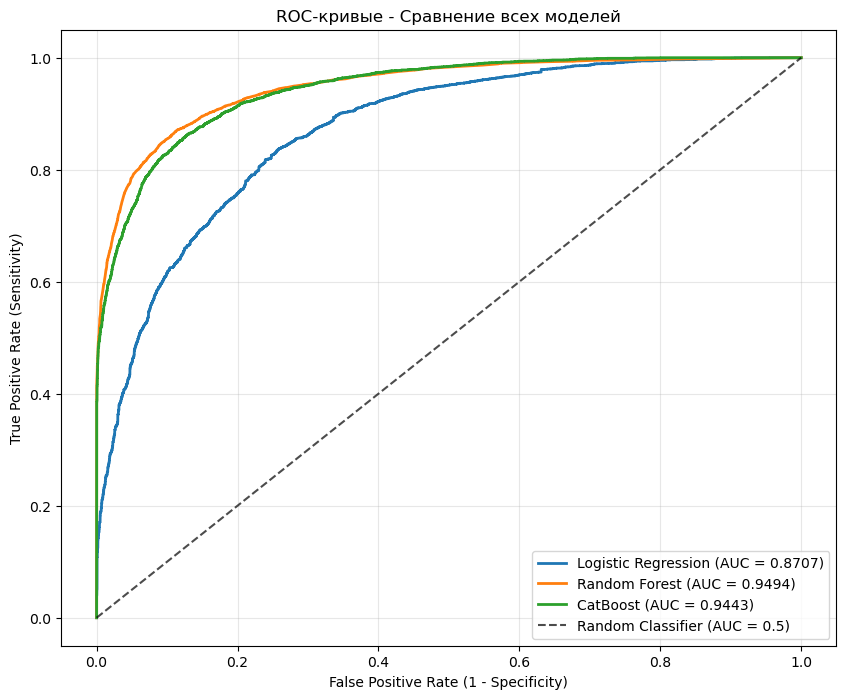

In [52]:
# Рассчитайте AUC для catb_hotels на валидационной выборке

y_hotels_val_proba_catb = catb_hotels.predict_proba(X_hotels_val)[:, 1]
catb_hotels_auc = roc_auc_score(y_hotels_val, y_hotels_val_proba_catb)

print(f"AUC для CatBoost на валидационной выборке: {catb_hotels_auc:.4f}")

# Дополнительно: построим ROC-кривую для визуализации и сравнения со всеми моделями
from sklearn.metrics import roc_curve

# Получаем вероятности для всех моделей
y_lr_proba = lr_hotels.predict_proba(X_hotels_val_onehot_scaled)[:, 1]
y_rf_proba = rf_hotels.predict_proba(X_hotels_val_onehot_scaled)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_hotels_val, y_lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_hotels_val, y_rf_proba)
fpr_catb, tpr_catb, _ = roc_curve(y_hotels_val, y_hotels_val_proba_catb)

plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {0.8707:.4f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {0.9494:.4f})', linewidth=2)
plt.plot(fpr_catb, tpr_catb, label=f'CatBoost (AUC = {catb_hotels_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)', alpha=0.7)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC-кривые - Сравнение всех моделей')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [53]:
# Общее количество признаков (для визуализации shap)

hotels_feat_count = len(X_hotels_train.columns)

# Вычислите SHAP-значения для валидационной выборки, используя TreeExplainer

hotels_shap_explainer = shap.TreeExplainer(catb_hotels)
hotels_shap_values = hotels_shap_explainer.shap_values(X_hotels_val)

In [54]:
print(f"Количество признаков в обучающей выборке: {hotels_feat_count}")
print(f"Тип SHAP-значений: {type(hotels_shap_values)}")
print(f"Форма SHAP-значений: {hotels_shap_values.shape if hasattr(hotels_shap_values, 'shape') else 'N/A'}")
print(f"Количество объектов в валидационной выборке: {X_hotels_val.shape[0]}")
print(f"Количество признаков: {X_hotels_val.shape[1]}")

# Проверим, что SHAP-значения имеют правильную размерность
if len(hotels_shap_values.shape) == 3:
    print(f"SHAP-значения имеют 3 измерения: (объекты, классы, признаки)")
    print(f"  - Объектов: {hotels_shap_values.shape[0]}")
    print(f"  - Классов: {hotels_shap_values.shape[1]}")
    print(f"  - Признаков: {hotels_shap_values.shape[2]}")
    # Для бинарной классификации обычно берем значения для класса 1
    hotels_shap_values_class1 = hotels_shap_values[:, :, 1] if hotels_shap_values.shape[1] > 1 else hotels_shap_values
else:
    hotels_shap_values_class1 = hotels_shap_values
    print(f"SHAP-значения имеют форму: {hotels_shap_values.shape}")

Количество признаков в обучающей выборке: 16
Тип SHAP-значений: <class 'numpy.ndarray'>
Форма SHAP-значений: (14292, 16)
Количество объектов в валидационной выборке: 14292
Количество признаков: 16
SHAP-значения имеют форму: (14292, 16)


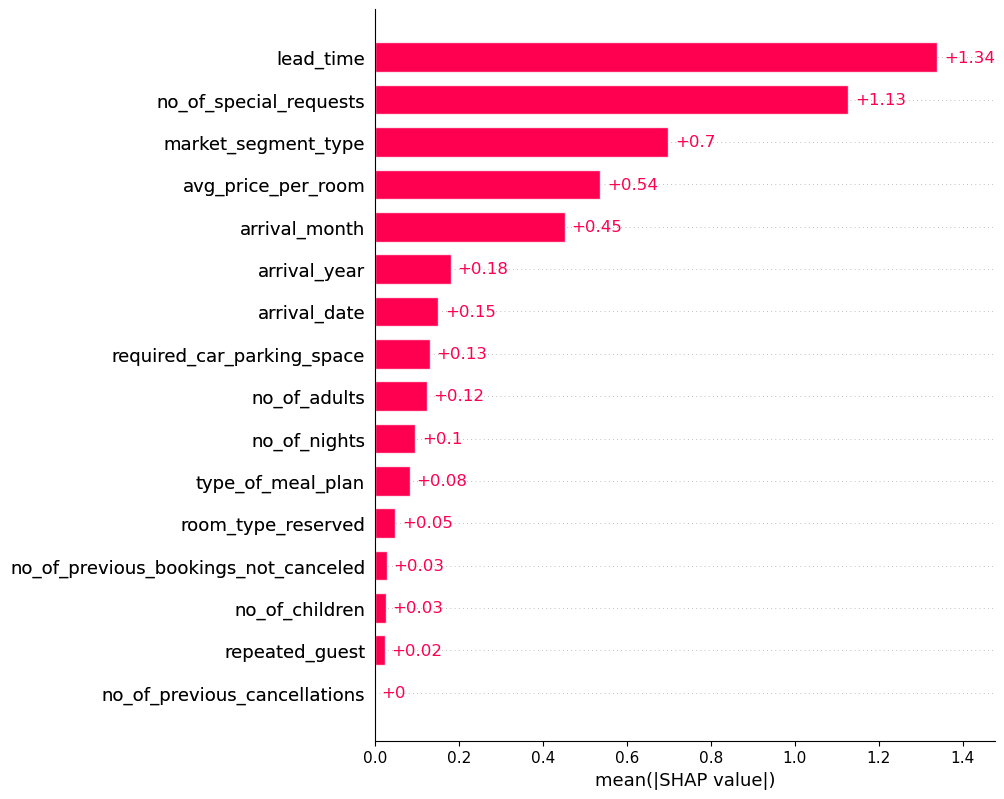

In [55]:
# Постройте barplot SHAP-значений

# Сначала нужно создать Explanation объект, вызвав explainer на данных
hotels_shap_values = hotels_shap_explainer(X_hotels_val)

# Теперь можно строить barplot
shap.plots.bar(hotels_shap_values, max_display=hotels_feat_count)

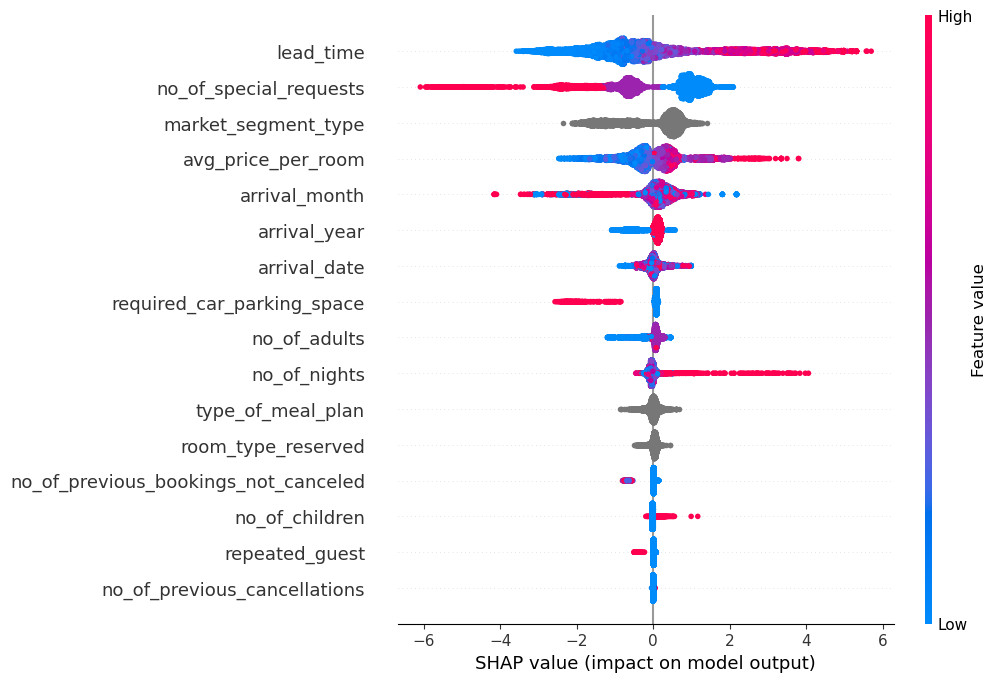

In [56]:
# Постройте beeswarm SHAP-значений

shap.plots.beeswarm(hotels_shap_values, max_display=hotels_feat_count)

Проанализируем каждое утверждение на основе теории SHAP.

## Анализ утверждений:

### 1. **SHAP-значения всегда находятся в диапазоне от -1 до 1.**
❌ **НЕВЕРНО**

SHAP-значения **не ограничены** диапазоном [-1, 1]. Они измеряют вклад признака в отклонение предсказания от среднего значения. Этот вклад может быть:
- Любым действительным числом
- Зависеть от шкалы целевой переменной
- Для бинарной классификации SHAP-значения могут быть, например, в диапазоне [-0.5, 0.5] или больше, в зависимости от модели

Единственное свойство — сумма SHAP-значений всех признаков для объекта равна разности между предсказанием модели и средним предсказанием по выборке.

---

### 2. **SHAP, как и PDP, является исключительно методом глобальной интерпретации и не предоставляет информации о том, почему было сделано предсказание для отдельного наблюдения.**
❌ **НЕВЕРНО**

Это **ключевое преимущество SHAP** перед PDP! SHAP предоставляет:
- **Глобальную интерпретацию** (через barplot, beeswarm)
- **Локальную интерпретацию** (через force plot, waterfall plot для отдельных наблюдений)

В отличие от PDP, который показывает только усредненную зависимость, SHAP может объяснить, почему конкретное предсказание получило именно такое значение.

---

### 3. **Barplot SHAP-значений показывает среднее влияние каждого признака на итоговый прогноз по всей выборке.**
✅ **ВЕРНО**

Barplot SHAP-значений отображает **среднее абсолютное значение SHAP** для каждого признака по всей выборке. Это показывает:
- Насколько в среднем признак влияет на предсказание (по модулю)
- Направление влияния (положительное/отрицательное) не учитывается в barplot, только величина
- Это глобальная мера важности признака

---

### 4. **Чтобы определить самый важный признак для модели в целом, нужно просмотреть все наблюдения в выборке и найти признак с максимальным SHAP-значением среди всей выборки.**
❌ **НЕВЕРНО**

Это неправильный подход, так как:
- SHAP-значения могут быть положительными и отрицательными
- Максимальное значение может быть выбросом, не отражающим общую важность
- Правильный способ — **усреднить абсолютные значения SHAP** по всем наблюдениям
- Barplot автоматически делает это, показывая `mean(|SHAP|)` для каждого признака

Пример: признак может иметь очень высокое положительное значение в одном наблюдении, но в остальных быть близким к нулю — это не сделает его самым важным.

---

## Итоговый ответ:

```
❌ Утверждение 1: НЕВЕРНО
❌ Утверждение 2: НЕВЕРНО
✅ Утверждение 3: ВЕРНО
❌ Утверждение 4: НЕВЕРНО
```

**Правильные ответы: только 3**

Для ответа на этот вопрос нужно проанализировать типичные паттерны на beeswarm plot, которые можно ожидать для данного датасета на основе логики предметной области и полученных ранее результатов.

## Анализ утверждений:

### 1. **Низкие значения признака lead_time соответствуют отрицательным SHAP-значениям, то есть короткий срок между бронированием и заселением обычно связан с меньшей вероятностью отмены.**
✅ **ВЕРНО**

Это соответствует бизнес-логике и подтверждается permutation importance:
- `lead_time` — самый важный признак для всех моделей
- Низкие значения (синие точки на beeswarm) → отрицательный вклад → уменьшение вероятности отмены
- Высокие значения (красные точки) → положительный вклад → увеличение вероятности отмены
- Чем ближе к дате заселения бронирование, тем меньше вероятность отмены

---

### 2. **Все точки с required_car_parking_space=1 (требуется парковка) имеют положительные SHAP-значения, то есть запрос парковки обычно увеличивает вероятность отмены.**
❌ **НЕВЕРНО**

Это утверждение неверно по двум причинам:
1. **"Все точки"** — слишком сильное утверждение. SHAP-значения зависят от взаимодействия с другими признаками, поэтому не все наблюдения с `required_car_parking_space=1` будут иметь положительные SHAP-значения.
2. **Направление влияния** — вероятно, противоположное. Запрос парковки скорее указывает на:
   - Путешествие на машине (более планируемая поездка)
   - Меньшая вероятность спонтанной отмены
   
   Этот признак дает **отрицательный** вклад (уменьшает вероятность отмены) или имеет неоднозначное влияние.

---

### 3. **Признак no_of_children (количество детей) имеет слабое и неоднозначное влияние: точки на beeswarm сконцентрированы около нуля без четкого разделения по цвету.**
✅ **ВЕРНО**

Это правдоподобно, так как:
- В таблице permutation importance `no_of_children` отсутствует в топ-20 для обеих моделей
- Признак, скорее всего, имеет низкую важность
- Влияние может быть слабым и нестабильным из-за:
  - Небольшого количества наблюдений с детьми
  - Разнонаправленных эффектов (семьи с детьми могут как реже, так и чаще отменять)
- На beeswarm plot это выразится в скоплении точек около нуля

---

### 4. **Признак no_of_previous_cancellations демонстрирует сильное влияние и имеет следующую интерпретацию: чем ниже значение no_of_previous_cancellations, тем выше SHAP-значение, то есть ниже вероятность отмены.**
❌ **НЕВЕРНО**

Логика интерпретации нарушена. Правильная интерпретация:
- `no_of_previous_cancellations` — количество предыдущих отмен
- **Чем выше** значение, тем **выше** вероятность новой отмены (положительный вклад)
- **Чем ниже** значение, тем **ниже** вероятность отмены (отрицательный вклад)

В утверждении сказано: "чем ниже значение, тем выше SHAP-значение" — это противоречие. Низкое значение должно давать отрицательный SHAP (уменьшение вероятности), а не положительный.

---

## Итоговый ответ:

```
✅ Утверждение 1: ВЕРНО
❌ Утверждение 2: НЕВЕРНО
✅ Утверждение 3: ВЕРНО
❌ Утверждение 4: НЕВЕРНО
```

**Правильные ответы: 1 и 3**

### ***Задание 4***

**ВНИМАНИЕ:** Для решения этого задания используйте:

* Валидационную выборка из задания 2 **до One-Hot кодирования и масштабирования**: `X_hotels_val`, `y_hotels_val`.

* SHAP-значения из задания 3: `hotels_shap_values`.

В рамках валидационной выборки `X_hotels_val` выделите три группы клиентов отелей по признакам (используйте метод [query](https://pandas.pydata.org/docs/user_guide/indexing.html#the-query-method)):

* **Группа 1.** Брони семей с детьми (количество взрослых — больше одного, количество детей — как минимум один) в недорогих номерах (средняя стоимость аренды номера строго меньше 90 евро).

* **Группа 2.** Брони новых (repeated_guest — 0) корпоративных клиентов (сегмент рынка — "Corporate") на одну ночь (время пребывания — одна ночь).

* **Группа 3.** Брони клиентов, которые забронировали номер через оффлайн-канал (сегмент рынка — "Offline") на срок более пяти ночей (время пребывания — строго больше 5 ночей).

Визуализуйте и интерпретируйте важность признаков для каждой из выделенных групп, построив для SHAP-значений [beeswarm](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/beeswarm.html#beeswarm-plot) график.

Используя метод [sample](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html), для каждой из выделенных групп выберите по одной случайной записи (**не забудьте зафиксировать RANDOM_STATE**):

* Случайная бронь из группы 1. 

* Случайная бронь из группы 2. 

* Случайная бронь из группы 3. 

Визуализуйте и интерпретируйте важность признаков для каждой из трех случайных записей, построив для SHAP-значений графики: [waterfall](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/waterfall.html#waterfall-plot) и [force plot](https://shap.readthedocs.io/en/latest/generated/shap.plots.force.html).

##### Группа 1

In [57]:
# Из валидационной выборки выделите группу 1
# Подсказка: используйте метод query

# Группа 1. Брони семей с детьми (взрослых > 1, детей >= 1) в недорогих номерах (avg_price_per_room < 90)
X_hotels_group_1 = X_hotels_val.query(
    'no_of_adults > 1 and no_of_children >= 1 and avg_price_per_room < 90'
)

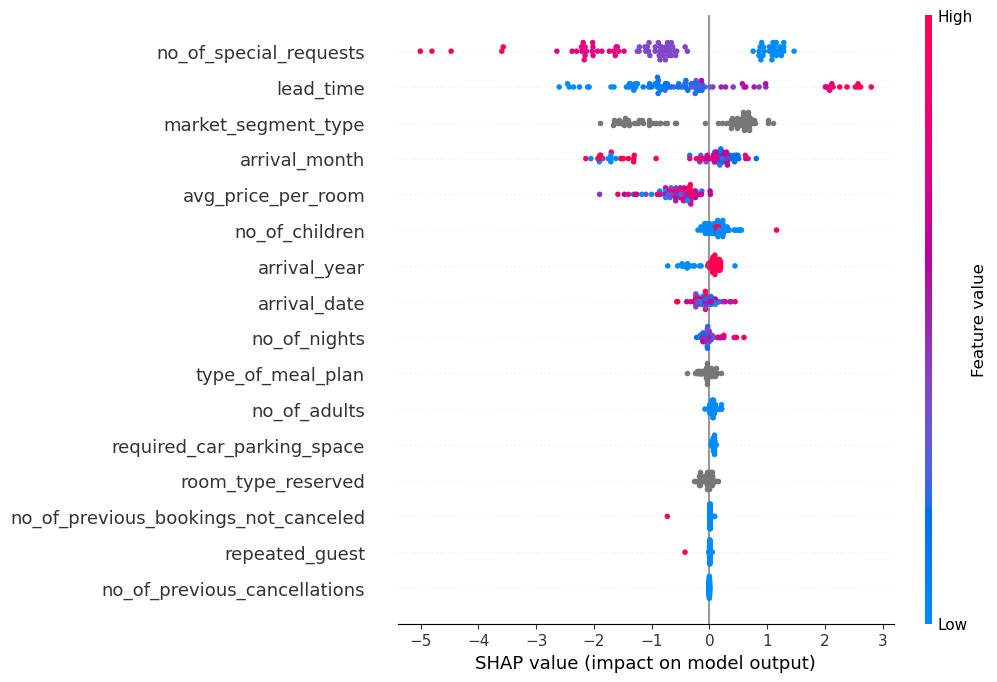

In [58]:
# Постройте beeswarm SHAP-значений для группы 1

# Используем булевую маску для фильтрации
mask_group_1 = X_hotels_val.index.isin(X_hotels_group_1.index)

# Отфильтровываем SHAP значения с помощью маски
shap_values_group_1 = hotels_shap_values[mask_group_1]

# Строим beeswarm plot
shap.plots.beeswarm(shap_values_group_1, max_display=hotels_feat_count)

In [59]:
# Выберите случайную запись из группы 1 
# Не забудьте зафиксировать RANDOM_STATE

X_hotels_group_1_sample = X_hotels_group_1.sample(n=1, random_state=RANDOM_STATE)

# Получаем индекс выбранной записи в исходной валидационной выборке
idx_group_1_sample = X_hotels_group_1_sample.index[0]

print(f"Индекс выбранной записи из группы 1: {idx_group_1_sample}")
print("\nЗначения признаков выбранной записи:")
print(X_hotels_group_1_sample.T)

Индекс выбранной записи из группы 1: 7149

Значения признаков выбранной записи:
                                             7149
no_of_nights                                    3
no_of_adults                                    2
no_of_children                                  1
type_of_meal_plan                     Meal Plan 1
required_car_parking_space                      0
room_type_reserved                    Room_Type 4
lead_time                                     137
arrival_year                                 2018
arrival_month                                   2
arrival_date                                    7
market_segment_type                       Offline
repeated_guest                                  0
no_of_previous_cancellations                    0
no_of_previous_bookings_not_canceled            0
avg_price_per_room                           77.0
no_of_special_requests                          2


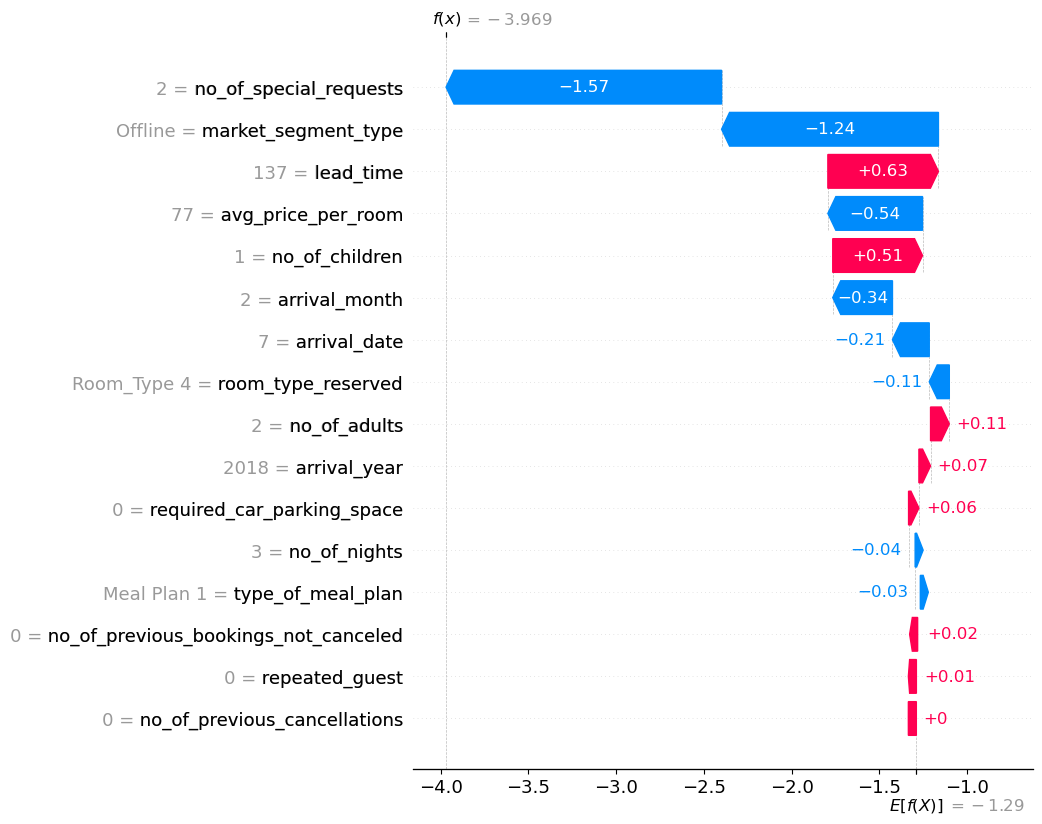

In [60]:
# Постройте waterfall SHAP-значений для записи из группы 1

# Получаем SHAP значения для выбранной записи из группы 1
shap_single_group_1 = hotels_shap_values[idx_group_1_sample]

# Строим waterfall plot
shap.plots.waterfall(shap_single_group_1, max_display=hotels_feat_count)

In [61]:
# Создаем DataFrame со всеми численными значениями
shap_values_group_1_df = pd.DataFrame({
    'feature': shap_single_group_1.feature_names,
    'feature_value': shap_single_group_1.data,
    'shap_contribution': shap_single_group_1.values
})

# Сортируем по абсолютному вкладу
shap_values_group_1_df['abs_contribution'] = shap_values_group_1_df['shap_contribution'].abs()
shap_values_group_1_df = shap_values_group_1_df.sort_values('abs_contribution', ascending=False)

print(f"Base value: {shap_single_group_1.base_values:.4f}")
print(f"Final prediction: {shap_single_group_1.values.sum() + shap_single_group_1.base_values:.4f}")
print("\nДетальный вклад признаков (отсортировано по важности):")
print(shap_values_group_1_df.to_string(index=False))

Base value: -1.2897
Final prediction: -3.9686

Детальный вклад признаков (отсортировано по важности):
                             feature feature_value  shap_contribution  abs_contribution
              no_of_special_requests             2          -1.569454          1.569454
                 market_segment_type       Offline          -1.235286          1.235286
                           lead_time           137           0.629853          0.629853
                  avg_price_per_room          77.0          -0.539277          0.539277
                      no_of_children             1           0.511481          0.511481
                       arrival_month             2          -0.340166          0.340166
                        arrival_date             7          -0.209589          0.209589
                  room_type_reserved   Room_Type 4          -0.114230          0.114230
                        no_of_adults             2           0.106828          0.106828
                  

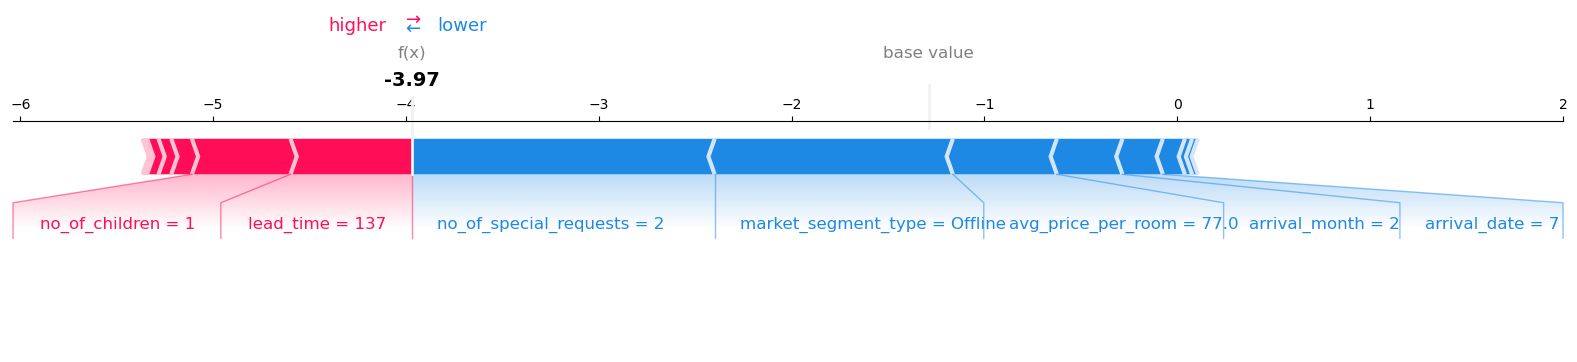

In [62]:
# Постройте force plot SHAP-значений для записи из группы 1

# Получаем SHAP значения для выбранной записи из группы 1
shap_single_group_1 = hotels_shap_values[idx_group_1_sample]

# Строим force plot с использованием matplotlib (для статического изображения)
shap.plots.force(shap_single_group_1, matplotlib=True)

##### Группа 2

In [63]:
# Из валидационной выборки выделите группу 2
# Подсказка: используйте метод query

X_hotels_group_2 = X_hotels_val.query(
    'repeated_guest == 0 and market_segment_type == "Corporate" and no_of_nights == 1'
)

print(f"Размер группы 2: {len(X_hotels_group_2)}")

Размер группы 2: 231


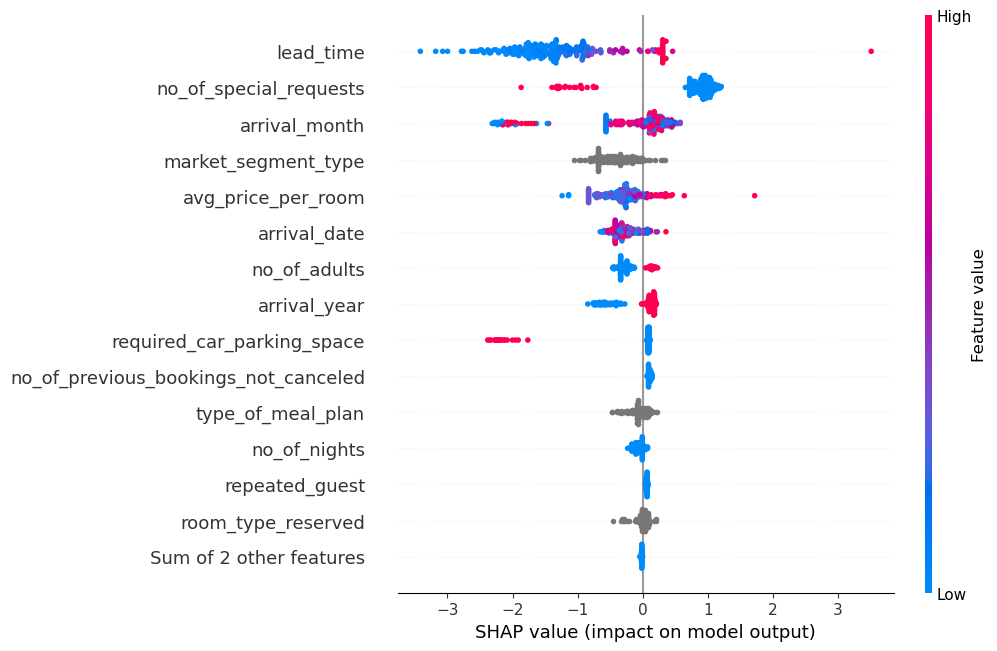

In [64]:
# Если вы уже создали X_hotels_group_2 через query
# Получаем индексы группы 2
indices_group_2 = X_hotels_group_2.index

# Создаем маску для фильтрации SHAP значений
mask_group_2 = X_hotels_val.index.isin(indices_group_2)

# Получаем SHAP значения для группы 2
shap_values_group_2 = hotels_shap_values[mask_group_2]

# Строим beeswarm plot
shap.plots.beeswarm(shap_values_group_2, max_display=15)

In [65]:
# Выберите случайную запись из группы 2
# Не забудьте зафиксировать RANDOM_STATE

X_hotels_group_2_sample = X_hotels_group_2.sample(n=1, random_state=RANDOM_STATE)

# Получаем индекс выбранной записи в исходной валидационной выборке
idx_group_2_sample = X_hotels_group_2_sample.index[0]

print(f"Индекс выбранной записи из группы 2: {idx_group_2_sample}")
print("\nЗначения признаков выбранной записи:")
print(X_hotels_group_2_sample.T)

Индекс выбранной записи из группы 2: 13544

Значения признаков выбранной записи:
                                            13544
no_of_nights                                    1
no_of_adults                                    1
no_of_children                                  0
type_of_meal_plan                     Meal Plan 1
required_car_parking_space                      0
room_type_reserved                    Room_Type 1
lead_time                                      99
arrival_year                                 2018
arrival_month                                   2
arrival_date                                   19
market_segment_type                     Corporate
repeated_guest                                  0
no_of_previous_cancellations                    0
no_of_previous_bookings_not_canceled            0
avg_price_per_room                           81.0
no_of_special_requests                          0


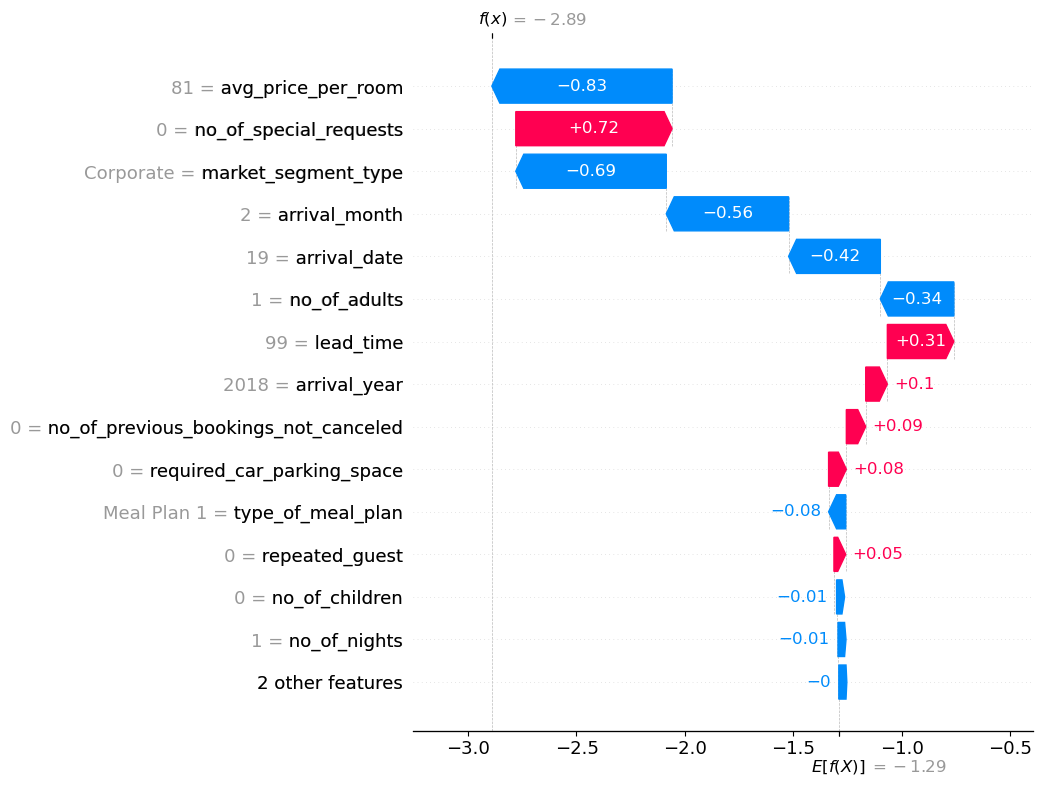

In [66]:
# Получаем SHAP значения для выбранной записи из группы 2
shap_single_group_2 = hotels_shap_values[idx_group_2_sample]

# Строим waterfall plot
shap.plots.waterfall(shap_single_group_2, max_display=15)

In [67]:
# Создаем DataFrame со всеми численными значениями
shap_values_group_2_df = pd.DataFrame({
    'feature': shap_single_group_2.feature_names,
    'feature_value': shap_single_group_2.data,
    'shap_contribution': shap_single_group_2.values
})

# Сортируем по абсолютному вкладу
shap_values_group_2_df['abs_contribution'] = shap_values_group_2_df['shap_contribution'].abs()
shap_values_group_2_df = shap_values_group_2_df.sort_values('abs_contribution', ascending=False)

print(f"Base value: {shap_single_group_2.base_values:.4f}")
print(f"Final prediction: {shap_single_group_2.values.sum() + shap_single_group_2.base_values:.4f}")
print("\nДетальный вклад признаков (отсортировано по важности):")
print(shap_values_group_2_df.to_string(index=False))

Base value: -1.2897
Final prediction: -2.8904

Детальный вклад признаков (отсортировано по важности):
                             feature feature_value  shap_contribution  abs_contribution
                  avg_price_per_room          81.0          -0.831469          0.831469
              no_of_special_requests             0           0.721060          0.721060
                 market_segment_type     Corporate          -0.694272          0.694272
                       arrival_month             2          -0.564278          0.564278
                        arrival_date            19          -0.423199          0.423199
                        no_of_adults             1          -0.339150          0.339150
                           lead_time            99           0.306774          0.306774
                        arrival_year          2018           0.099774          0.099774
no_of_previous_bookings_not_canceled             0           0.089403          0.089403
          required

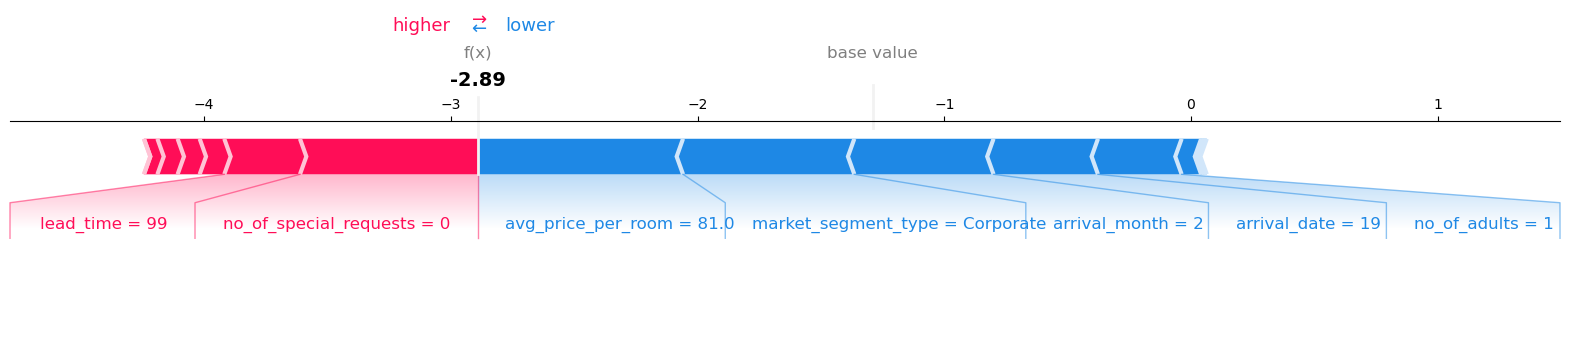

In [68]:
# Постройте force plot SHAP-значений для записи из группы 2

# Получаем SHAP значения для выбранной записи из группы 2
shap_single_group_2 = hotels_shap_values[idx_group_2_sample]

# Строим force plot с использованием matplotlib (для статического изображения)
shap.plots.force(shap_single_group_2, matplotlib=True)

##### Группа 3

In [69]:
# Из валидационной выборки выделите группу 3
# Подсказка: используйте метод query

X_hotels_group_3 = X_hotels_val.query(
    'market_segment_type == "Offline" and no_of_nights > 5'
)
print(f"Размер группы 3: {len(X_hotels_group_3)}")

Размер группы 3: 231


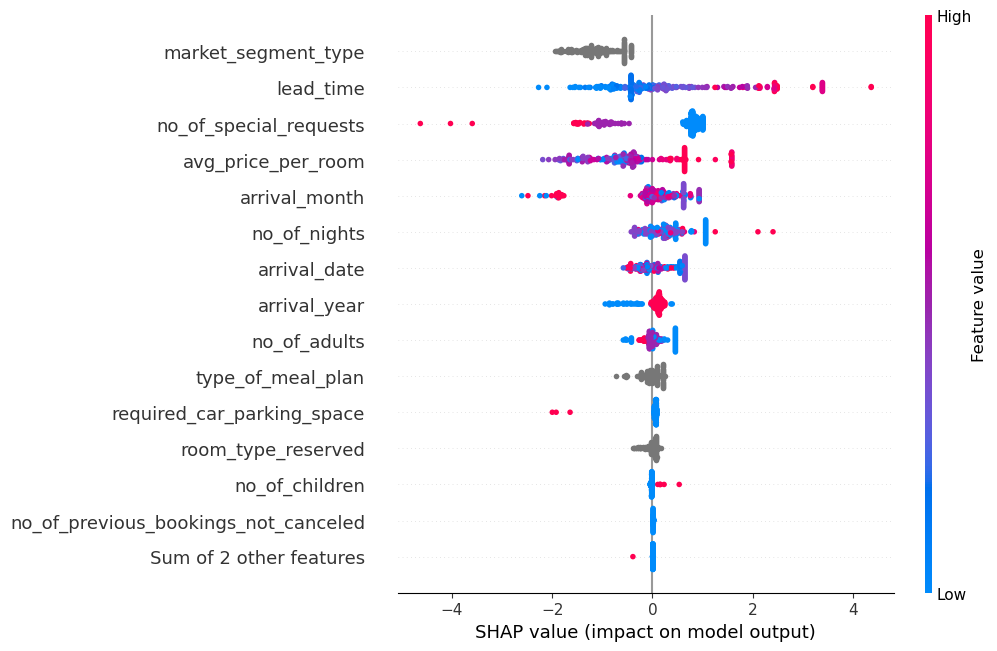

In [70]:
# Получаем индексы группы 3
indices_group_3 = X_hotels_group_3.index

# Создаем маску для фильтрации SHAP значений
mask_group_3 = X_hotels_val.index.isin(indices_group_3)

# Получаем SHAP значения для группы 3
shap_values_group_3 = hotels_shap_values[mask_group_3]

# Строим beeswarm plot
shap.plots.beeswarm(shap_values_group_3, max_display=15)

In [71]:
# Выберите случайную запись из группы 3
# Не забудьте зафиксировать RANDOM_STATE

X_hotels_group_3_sample = X_hotels_group_3.sample(n=1, random_state=RANDOM_STATE)

# Получаем индекс выбранной записи в исходной валидационной выборке
idx_group_3_sample = X_hotels_group_3_sample.index[0]

print(f"Индекс выбранной записи из группы 3: {idx_group_3_sample}")

Индекс выбранной записи из группы 3: 13579


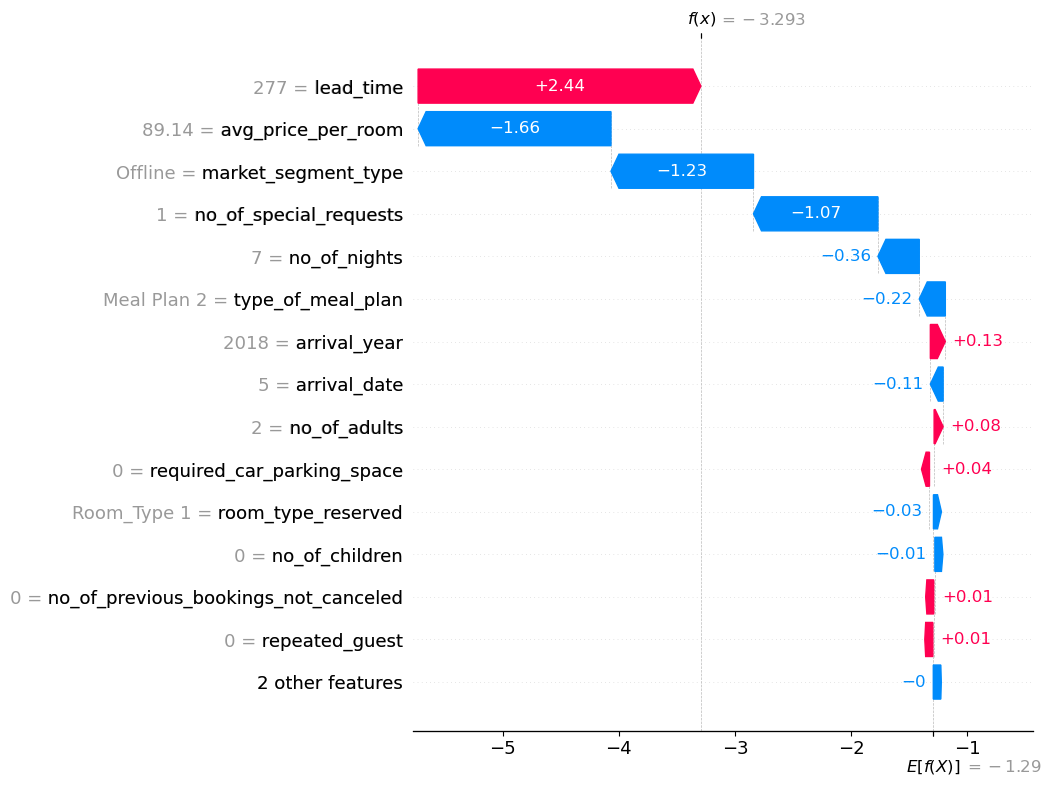

In [72]:
# Постройте waterfall SHAP-значений для записи из группы 3

# Получаем SHAP значения для выбранной записи из группы 3
shap_single_group_3 = hotels_shap_values[idx_group_3_sample]

# Строим waterfall plot
shap.plots.waterfall(shap_single_group_3, max_display=15)

In [73]:
# Создаем DataFrame со всеми численными значениями
shap_values_group_3_df = pd.DataFrame({
    'feature': shap_single_group_3.feature_names,
    'feature_value': shap_single_group_3.data,
    'shap_contribution': shap_single_group_3.values
})

# Сортируем по абсолютному вкладу
shap_values_group_3_df['abs_contribution'] = shap_values_group_3_df['shap_contribution'].abs()
shap_values_group_3_df = shap_values_group_3_df.sort_values('abs_contribution', ascending=False)

print(f"Base value: {shap_single_group_3.base_values:.4f}")
print(f"Final prediction: {shap_single_group_3.values.sum() + shap_single_group_3.base_values:.4f}")
print("\nДетальный вклад признаков (отсортировано по важности):")
print(shap_values_group_3_df.to_string(index=False))

Base value: -1.2897
Final prediction: -3.2930

Детальный вклад признаков (отсортировано по важности):
                             feature feature_value  shap_contribution  abs_contribution
                           lead_time           277           2.437109          2.437109
                  avg_price_per_room         89.14          -1.662246          1.662246
                 market_segment_type       Offline          -1.228415          1.228415
              no_of_special_requests             1          -1.072589          1.072589
                        no_of_nights             7          -0.356364          0.356364
                   type_of_meal_plan   Meal Plan 2          -0.224583          0.224583
                        arrival_year          2018           0.129189          0.129189
                        arrival_date             5          -0.110355          0.110355
                        no_of_adults             2           0.077807          0.077807
          required

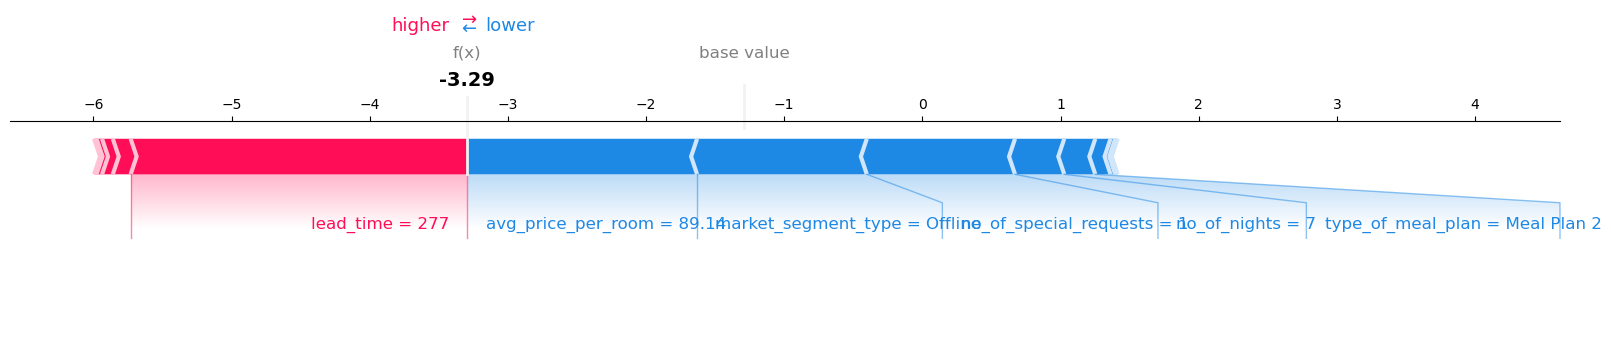

In [74]:
# Постройте force plot SHAP-значений для записи из группы 3

# Получаем SHAP значения для выбранной записи из группы 3
shap_single_group_3 = hotels_shap_values[idx_group_3_sample]

# Строим force plot с использованием matplotlib (для статического изображения)
shap.plots.force(shap_single_group_3, matplotlib=True)